# JackSparrow v21 — BTC Perp ML Trading System

**v21 improvements over v20:**

- `[v21-1]` **Directional Classifier + Calibrated Regressor ensemble**: Replace pure XGBRegressor with a 2-stage pipeline — XGBClassifier (direction) × XGBRegressor (magnitude). Signal fires only when both agree.
- `[v21-2]` **5m lookahead reduced 30→15 bars** (75 min), 15m lookahead reduced 24→12 bars (3h). Shorter horizons → cleaner labels, less noise contamination.
- `[v21-3]` **SMOTE-free class balancing via focal-loss-inspired sample weighting** with per-class temperature scaling. Replaces power-scale weighting that over-amplified noise.
- `[v21-4]` **Realistic-first backtest**: PRIMARY profile now uses `exec_delay=1` (next-bar open). Baseline kept for reference only. Prevents overfitting to zero-latency execution.
- `[v21-5]` **Feature engineering overhaul**: Added price-action microstructure (OBI proxy, gap-open, VWAP deviation), removed highly-lagged EMA pairs that bleed autocorrelation.
- `[v21-6]` **Walk-forward expanding window CV** with PearsonR gating: folds with |PearsonR| < 0.02 are discarded — signals the model has no usable regression signal.
- `[v21-7]` **Tighter cost model**: `LABEL_MIN_NET_EDGE` raised to 30 bps (was 20 bps) to require stronger gross alpha before labeling BUY/SELL.
- `[v21-8]` **Adaptive EDGE_FLOOR per-timeframe**: 5m uses 30 bps floor, 15m uses 25 bps (was uniform 20 bps). Reduces 5m over-trading.
- `[v21-9]` **Daily loss circuit breaker**: halt trading if intraday drawdown > 2% (5m) / 3% (15m).
- `[v21-10]` **Holdout Sharpe printed per-fold** to detect overfitting early.

**v20 fixes retained (no regressions):** EDGE_FLOOR decimal unit fix, CONFIDENCE_PERCENTILE=80, ADX regime filter, extended drift detection, ModelRegistry hot-swap.


In [7]:
# Cell 1: Setup — JackSparrow v21
# [v21-1] 2-stage ensemble: XGBClassifier (direction) × XGBRegressor (magnitude)
# [v21-4] Realistic-first: primary backtest uses exec_delay=1
# [v21-7] LABEL_MIN_NET_EDGE raised to 30 bps

import subprocess, sys

pkgs = [
    "xgboost==2.0.2", "scikit-learn", "pandas", "numpy",
    "requests", "joblib", "matplotlib", "seaborn", "shap",
    "tqdm", "numba", "imbalanced-learn", "scipy",
]
try:
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet"] + pkgs, check=True)
except subprocess.CalledProcessError as e:
    print(f"[WARN] pip install partial failure: {e}")

import requests, time, json, joblib, shap, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from copy import deepcopy
from scipy.stats import ks_2samp, pearsonr
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone
import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings("ignore")

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print('Google Drive mount skipped (not in Colab)')

BASE_URL   = "https://api.india.delta.exchange/v2"
SYMBOL     = "BTCUSD"
PRODUCT_ID = 27
TIMEFRAMES = ["5m", "15m"]

OUTPUT_DIR = (
    Path("/content/drive/MyDrive/JackSparrow_Models")
    if Path("/content/drive").exists()
    else Path("./models")
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONTRACT_VALUE_BTC = 0.001
TAKER_FEE          = 0.0005

# [v18-3] Layered cost model
SPREAD_BPS           = 5
SLIPPAGE_BASE_BPS    = 5
SLIPPAGE_VOL_COEF    = 0.10

# [v21-4] REALISTIC-FIRST: primary profile uses delay=1 (next-bar open fill)
EXECUTION_DELAY_BARS           = 1   # [v21-4] was 0 — realistic-first
EXECUTION_DELAY_BARS_BASELINE  = 0   # kept for reference comparison
BACKTEST_RUN_DUAL              = True

FIFTEEN_M_SOURCE = "resample_5m"

MIN_COVERAGE_PCT           = 85.0
MIN_COVERAGE_PCT_15M_API   = 95.0
MIN_COVERAGE_RESAMPLED_15M = 97.0

# [v21-7] Tighter cost threshold — require stronger gross alpha
LABEL_MIN_NET_EDGE    = 0.0030   # [v21-7] raised from 0.0020 (20→30 bps)
LABEL_MIN_ATR_PCT     = 0.0020

# [v21-2] Shorter lookahead: cleaner labels, less noise
TF_LOOKAHEAD = {"5m": 15, "15m": 12}   # [v21-2] was 30/24

# [v21-8] Per-timeframe edge floors
EDGE_FLOOR_TF = {"5m": 0.0030, "15m": 0.0025}   # [v21-8]
EDGE_FLOOR     = 0.0030  # default (5m) — backtest fn uses EDGE_FLOOR_TF[tf]

CONFIDENCE_PERCENTILE = 80   # rolling top-20% filter

TRAIN_EXEC_DELAY_BARS = 1
TRAIN_SPREAD_BPS      = 5
TRAIN_SLIPPAGE_BPS    = 8
SLIPPAGE_BPS          = 10

# Trade management
ATR_TRAILING_MULT         = 1.5
MIN_HOLD_BARS             = 5
EDGE_DECAY_THRESHOLD      = 0.05
VOLATILITY_FILTER_PCT     = 0.002

# [v21-9] Daily loss circuit breaker
DAILY_DD_LIMIT_TF = {"5m": 0.02, "15m": 0.03}   # [v21-9]

# Regime filter
ADX_REGIME_MIN            = 15.0
ADX_REGIME_MAX            = 60.0
MIN_PROFIT_BEFORE_TRAIL   = 0.003

# Multi-timeframe confirmation
USE_15M_CONFIRMATION      = True
TF_CONFIRM_COL_5M         = "ema_cross_50_200_15m"

# Edge sizing
ENABLE_EDGE_POSITION_SIZING = True
EDGE_SIZE_SCALE             = 0.0040
MIN_POSITION_SIZE           = 0.20
MAX_POSITION_SIZE           = 1.00

MIN_EDGE_COST_RATIO   = 2.0
MIN_GAP_CANDLES       = 3
TF_MAX_TRADES_DAY     = {"5m": 6, "15m": 4}   # [v21] 5m reduced from 8

TOP_N_FEATURES   = 20
CORR_THRESHOLD   = 0.92   # [v21] tighter from 0.95
HOLDOUT_FRAC     = 0.20

LABEL_MODE = "cost_aware"
TP_LONG_PCT  = 0.012
SL_LONG_PCT  = 0.005
TP_SHORT_PCT = 0.010
SL_SHORT_PCT = 0.005

RANDOM_STATE = 42

# Retrain / lifecycle
ROLLING_DAYS                = 60
DRIFT_FEATURE_LIMIT         = 5
DRIFT_ALPHA                 = 0.01
DRIFT_STAT_THRESHOLD        = 0.10
RETRAIN_COOLDOWN_HOURS      = 24
MIN_RETRAIN_SAMPLES         = 20_000
DRIFT_PERSISTENCE_CYCLES    = 3
VALIDATION_WINDOW_ROWS      = 10_000
MIN_VAL_ROWS                = 500
MAX_MISSING_DATA_RATIO_DRIFT = 0.15
NUM_BOOST_ROUND_INCREMENTAL = 150
NAN_OHLC_DROP_INSTEAD_OF_FFILL = True
FFILL_GAP_LIMIT = 3

MAX_LOOKAHEAD = max(TF_LOOKAHEAD.values())
TF_BARS_PER_8H = {"5m": 96, "15m": 32}
TF_BARS_PER_YEAR = {"5m": 105_120, "15m": 35_040}

def effective_15m_target_rows(n_bars_5m, cap=100_000):
    return min(cap, max(0, n_bars_5m // 3))

def coverage_gate_passes(tf, raw_data):
    if tf not in raw_data or raw_data[tf] is None or len(raw_data[tf]) == 0:
        return False, 0.0, "missing"
    n = len(raw_data[tf])
    if tf == "5m":
        target = 200_000
        pct = n / target * 100
        return pct >= MIN_COVERAGE_PCT, pct, f"{n:,}/{target:,}"
    if tf == "15m":
        if FIFTEEN_M_SOURCE == "resample_5m":
            df5 = raw_data.get("5m")
            n5 = len(df5) if df5 is not None else 0
            implied = max(1, n5 // 3)
            pct = n / implied * 100
            return pct >= MIN_COVERAGE_RESAMPLED_15M, pct, f"{n:,}/~{implied:,} (from 5m)"
        target = 100_000
        pct = n / target * 100
        return pct >= MIN_COVERAGE_PCT_15M_API, pct, f"{n:,}/{target:,}"
    return True, 100.0, "n/a"

print("Setup complete (v21)")
print(f"  LABEL_MIN_NET_EDGE: {LABEL_MIN_NET_EDGE:.2%}  [v21-7: raised from 20→30 bps]")
print(f"  TF_LOOKAHEAD      : {TF_LOOKAHEAD}  [v21-2: shortened]")
print(f"  EDGE_FLOOR_TF     : {EDGE_FLOOR_TF}  [v21-8: per-tf]")
print(f"  Primary exec delay: {EXECUTION_DELAY_BARS} bar(s)  [v21-4: realistic-first]")
print(f"  DAILY_DD_LIMIT_TF : {DAILY_DD_LIMIT_TF}  [v21-9: circuit breaker]")
print(f"  CORR_THRESHOLD    : {CORR_THRESHOLD}  [v21: tighter]")
print(f"  Output dir        : {OUTPUT_DIR}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete (v21)
  LABEL_MIN_NET_EDGE: 0.30%  [v21-7: raised from 20→30 bps]
  TF_LOOKAHEAD      : {'5m': 15, '15m': 12}  [v21-2: shortened]
  EDGE_FLOOR_TF     : {'5m': 0.003, '15m': 0.0025}  [v21-8: per-tf]
  Primary exec delay: 1 bar(s)  [v21-4: realistic-first]
  DAILY_DD_LIMIT_TF : {'5m': 0.02, '15m': 0.03}  [v21-9: circuit breaker]
  CORR_THRESHOLD    : 0.92  [v21: tighter]
  Output dir        : /content/drive/MyDrive/JackSparrow_Models


In [8]:
# Cell 2: Fetch historical OHLCV — v21 (unchanged from v18/v20, stable)
import requests, time
import pandas as pd
import numpy as np

try:
    from tqdm.auto import tqdm as _tqdm
    HAS_TQDM = True
except ImportError:
    HAS_TQDM = False

MAX_CANDLES_PER_REQ = 2000
REQUEST_DELAY       = 0.12
MAX_RETRIES         = 3
OHLCV_COLS          = ["open", "high", "low", "close", "volume"]
HEADERS             = {"User-Agent": "python-rest-client/1.0", "Accept": "application/json"}
TF_TO_SECONDS       = {"5m": 300, "15m": 900}
TF_TARGET_CANDLES   = {"5m": 200_000, "15m": 100_000}
GAP_BUFFER_RATIO    = 1.10
NO_PROGRESS_STEP_BARS = 10


def align_ts_floor_utc(ts, resolution_s):
    return (int(ts) // resolution_s) * resolution_s


def resample_5m_ohlcv_to_15m(df5):
    if df5 is None or df5.empty:
        return pd.DataFrame()
    d = df5.sort_values("datetime").copy().set_index("datetime")
    if d.index.tz is None:
        d.index = d.index.tz_localize("UTC")
    ohlc = d[OHLCV_COLS].resample("15min", label="right", closed="right").agg(
        {"open": "first", "high": "max", "low": "min", "close": "last", "volume": "sum"})
    ohlc = ohlc.dropna(subset=["open","high","low","close"]).reset_index()
    first_col = ohlc.columns[0]
    if first_col != "datetime":
        ohlc = ohlc.rename(columns={first_col: "datetime"})
    ohlc["time"] = (ohlc["datetime"].astype("int64") // 1_000_000_000).astype("int64")
    return ohlc


def fetch_candles_delta_v10(symbol, resolution, target_candles):
    all_candles  = []
    resolution_s = TF_TO_SECONDS[resolution]
    now_ts       = int(time.time())
    current_end  = align_ts_floor_utc(now_ts - resolution_s, resolution_s)
    buffer_candles = int(target_candles * GAP_BUFFER_RATIO)
    hard_start_ts  = align_ts_floor_utc(current_end - (buffer_candles * resolution_s), resolution_s)
    window_size    = MAX_CANDLES_PER_REQ * resolution_s
    _req_count     = 0
    pbar = (_tqdm(total=target_candles, desc=f"{symbol} {resolution}", unit="candle",
                  dynamic_ncols=True, miniters=500) if HAS_TQDM else None)
    _prev_pbar_n = 0

    def _update_bar(done=False):
        nonlocal _prev_pbar_n
        if pbar is None: return
        new_n = min(len(all_candles), target_candles)
        delta = new_n - _prev_pbar_n
        if delta > 0: pbar.update(delta); _prev_pbar_n = new_n
        cur_date = pd.to_datetime(current_end, unit="s").strftime("%Y-%m-%d")
        pbar.set_postfix_str(f"window_end={cur_date}  reqs={_req_count}", refresh=False)
        if done: pbar.n = target_candles; pbar.close()

    while len(all_candles) < target_candles and current_end > hard_start_ts:
        current_start = max(current_end - window_size, hard_start_ts)
        current_start = align_ts_floor_utc(current_start, resolution_s)
        params = {"symbol": symbol, "resolution": resolution,
                  "start": int(current_start), "end": int(current_end)}
        prev_len = len(all_candles)
        for retry in range(MAX_RETRIES):
            try:
                r = requests.get(f"{BASE_URL}/history/candles", params=params,
                                 headers=HEADERS, timeout=30)
                r.raise_for_status()
                data = r.json()
                if not data.get("success"):
                    raise ValueError(f"API error: {data.get('error', data)}")
                batch = data.get("result", [])
                _req_count += 1
                if batch:
                    newest = pd.to_datetime(batch[0]["time"],  unit="s").strftime("%Y-%m-%d %H:%M")
                    oldest = pd.to_datetime(batch[-1]["time"], unit="s").strftime("%Y-%m-%d %H:%M")
                    print(f"  [{resolution}] req#{_req_count:04d}: {len(batch):4d} candles"
                          f" | {oldest} -> {newest} | total: {len(all_candles)+len(batch):,}")
                else:
                    print(f"  [{resolution}] EMPTY window")
                if not batch:
                    current_end = current_start - resolution_s; _update_bar(); break
                all_candles.extend(batch)
                current_end = align_ts_floor_utc(batch[-1]["time"] - resolution_s, resolution_s)
                _update_bar()
                if len(all_candles) >= target_candles:
                    _update_bar(done=True); return all_candles[:target_candles]
                time.sleep(REQUEST_DELAY); break
            except Exception as e:
                if retry == MAX_RETRIES - 1:
                    print(f"  Error after {MAX_RETRIES} retries: {e}")
                    if pbar: pbar.close()
                    return all_candles[:target_candles]
                time.sleep(2 ** retry)
        if len(all_candles) == prev_len:
            current_end -= NO_PROGRESS_STEP_BARS * resolution_s
            current_end = align_ts_floor_utc(current_end, resolution_s)
    if pbar: _update_bar(done=True)
    return all_candles[:target_candles]


def validate_and_clean(df, resolution):
    resolution_s = TF_TO_SECONDS[resolution]
    report = {}
    df = df.sort_values("time").reset_index(drop=True)
    for col in OHLCV_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")
    n_dups = df.duplicated(subset=["time"]).sum()
    if n_dups: print(f"  [{resolution}] {n_dups} duplicate timestamps removed.")
    df = df.drop_duplicates(subset=["time"]).reset_index(drop=True)
    report["duplicates_removed"] = int(n_dups)
    df["_delta"] = df["time"].diff()
    df["datetime"] = pd.to_datetime(df["time"], unit="s", utc=True)
    df = df.set_index("datetime")
    freq_alias = f"{resolution_s}s"
    full_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq=freq_alias, tz="UTC")
    df = df.reindex(full_idx)
    missing_mask = df["time"].isna()
    n_missing = int(missing_mask.sum())
    run_id = (missing_mask != missing_mask.shift()).cumsum()
    run_lens = missing_mask.groupby(run_id).transform("sum")
    large_gap = missing_mask & (run_lens > FFILL_GAP_LIMIT)
    df = df.ffill()
    df.loc[large_gap, OHLCV_COLS] = np.nan
    df["time"] = (df.index.astype("int64") // 1_000_000_000).astype("int64")
    df["datetime"] = df.index
    df = df.reset_index(drop=True).drop(columns=["_delta"], errors="ignore")
    now_ts = int(time.time())
    df = df[df["time"] <= now_ts - resolution_s].reset_index(drop=True)
    report.update({
        "raw_gaps": int(df["_delta"].notna().sum()) if "_delta" in df.columns else 0,
        "missing_bars": n_missing,
        "final_candles": len(df),
        "date_start": str(df["datetime"].min().date()) if len(df) else "N/A",
        "date_end": str(df["datetime"].max().date()) if len(df) else "N/A",
    })
    return df, report


raw_data = {}

# 5m
_tf5 = "5m"; _target5 = TF_TARGET_CANDLES[_tf5]
print(f"\n{'='*60}\nFetching {_tf5} | target={_target5:,}")
_c5 = fetch_candles_delta_v10(SYMBOL, _tf5, _target5)
if _c5:
    _c5 = list(reversed(_c5))
    _df5 = pd.DataFrame(_c5)
    _df5["datetime"] = pd.to_datetime(_df5["time"], unit="s", utc=True)
    _df5, _rep5 = validate_and_clean(_df5, _tf5)
    raw_data[_tf5] = _df5
    n5 = len(_df5)
    print(f"  5m: {n5:,} rows | {_df5['datetime'].min()} -> {_df5['datetime'].max()}")

# 15m via resample
if "5m" in raw_data and FIFTEEN_M_SOURCE == "resample_5m":
    print(f"\n{'='*60}\n[v18-1] Building 15m via resample from 5m")
    _df15 = resample_5m_ohlcv_to_15m(raw_data["5m"])
    raw_data["15m"] = _df15
    print(f"  15m: {len(_df15):,} rows")

print("\nAll fetches complete.")



Fetching 5m | target=200,000


BTCUSD 5m:   0%|          | 0/200000 [00:00<?, ?candle/s]

  [5m] req#0001: 2001 candles | 2026-04-10 15:15 -> 2026-04-17 13:55 | total: 2,001
  [5m] req#0002: 2001 candles | 2026-04-03 16:30 -> 2026-04-10 15:10 | total: 4,002
  [5m] req#0003: 2001 candles | 2026-03-27 17:45 -> 2026-04-03 16:25 | total: 6,003
  [5m] req#0004: 2001 candles | 2026-03-20 19:00 -> 2026-03-27 17:40 | total: 8,004
  [5m] req#0005: 2001 candles | 2026-03-13 20:15 -> 2026-03-20 18:55 | total: 10,005
  [5m] req#0006: 2001 candles | 2026-03-06 21:30 -> 2026-03-13 20:10 | total: 12,006
  [5m] req#0007: 2001 candles | 2026-02-27 22:45 -> 2026-03-06 21:25 | total: 14,007
  [5m] req#0008: 2001 candles | 2026-02-21 00:00 -> 2026-02-27 22:40 | total: 16,008
  [5m] req#0009: 2001 candles | 2026-02-14 01:15 -> 2026-02-20 23:55 | total: 18,009
  [5m] req#0010: 2001 candles | 2026-02-07 02:30 -> 2026-02-14 01:10 | total: 20,010
  [5m] req#0011: 2001 candles | 2026-01-31 03:45 -> 2026-02-07 02:25 | total: 22,011
  [5m] req#0012: 2001 candles | 2026-01-24 05:00 -> 2026-01-31 03:40 

In [9]:
# Cell 3: Feature Engineering — v21
# [v21-5] New microstructure features: VWAP deviation, gap-open, OBI proxy, realized-vol ratio
# Removed: highly-lagged EMA raw values (ema_100, ema_200 raw prices) — use normalized versions only

import numpy as np
import pandas as pd


def prepare_base_df(df):
    df = df.copy().sort_values("datetime").reset_index(drop=True)
    for col in ["open","high","low","close","volume"]:
        df[col] = df[col].astype(float)
    return df


def build_features(df):
    out = df.copy()
    c, h, l, o, v = (out[x].astype(float) for x in ["close","high","low","open","volume"])
    eps = 1e-10

    # ── Returns & momentum ─────────────────────────────────────────────────────
    out["returns"]     = c.pct_change(fill_method=None)
    out["log_returns"] = np.log(c / c.shift(1))
    out["roc_5"]  = c.pct_change(5,  fill_method=None)
    out["roc_10"] = c.pct_change(10, fill_method=None)
    out["roc_20"] = c.pct_change(20, fill_method=None)
    out["return_1"] = c.pct_change(1, fill_method=None)
    out["return_3"] = c.pct_change(3, fill_method=None)
    out["momentum_accel"] = out["return_3"] - out["return_1"]

    # ── ATR base ────────────────────────────────────────────────────────────────
    pc  = c.shift(1)
    tr  = pd.concat([(h-l), (h-pc).abs(), (l-pc).abs()], axis=1).max(axis=1)
    atr = tr.ewm(com=13, adjust=False).mean()
    atr_long = atr.rolling(50, min_periods=10).mean()

    out["atr_14"]  = atr
    out["atr_pct"] = atr / (c + eps)
    out["atr_ratio"] = atr / (atr_long + eps)   # vol regime: >1 = elevated

    # ── Realized vol ratio [v21-5] ──────────────────────────────────────────────
    ret = out["returns"]
    vol_5  = ret.rolling(5).std()
    vol_20 = ret.rolling(20).std()
    vol_60 = ret.rolling(60).std()
    out["vol_ratio_st_lt"] = vol_5  / (vol_20 + eps)
    out["vol_ratio_mt_lt"] = vol_20 / (vol_60 + eps)   # [v21-5]
    out["volatility"]    = vol_20
    out["volatility_10"] = ret.rolling(10).std()

    # ── VWAP deviation [v21-5] ──────────────────────────────────────────────────
    tp = (h + l + c) / 3
    vwap_20 = (tp * v).rolling(20).sum() / (v.rolling(20).sum() + eps)
    out["vwap_dev"] = (c - vwap_20) / (c + eps)   # [v21-5]

    # ── Gap-open [v21-5]: overnight/session gap ─────────────────────────────────
    out["gap_open"] = (o - c.shift(1)) / (c.shift(1) + eps)   # [v21-5]

    # ── OBI proxy [v21-5]: buying pressure from candle body direction + volume ──
    body_sign = np.sign(c - o)
    out["obi_proxy"] = (body_sign * v / (v.rolling(20).mean() + eps))   # [v21-5]
    out["obi_smooth"] = out["obi_proxy"].ewm(span=5, adjust=False).mean()

    # ── EMAs — normalized only (no raw price EMAs as features) ──────────────────
    ema9   = c.ewm(span=9,   adjust=False).mean()
    ema21  = c.ewm(span=21,  adjust=False).mean()
    ema50  = c.ewm(span=50,  adjust=False).mean()
    ema200 = c.ewm(span=200, adjust=False).mean()

    out["ema_9"]            = ema9   # kept for 15m cross reference
    out["ema_cross_9_21"]   = np.sign(ema9  - ema21)
    out["ema_cross_21_50"]  = np.sign(ema21 - ema50)
    out["ema_cross_50_200"] = np.sign(ema50 - ema200)
    out["price_vs_ema200"]  = (c - ema200) / (ema200 + eps)
    out["trend_strength"]   = (ema9 - ema50) / (ema50 + eps)
    out["ema_spread_9_200"] = (ema9 - ema200) / (c + eps)

    # ── MACD ────────────────────────────────────────────────────────────────────
    macd     = c.ewm(span=12,adjust=False).mean() - c.ewm(span=26,adjust=False).mean()
    macd_sig = macd.ewm(span=9, adjust=False).mean()
    out["macd"]        = macd
    out["macd_signal"] = macd_sig
    out["macd_hist"]   = macd - macd_sig
    out["macd_hist_slope"] = out["macd_hist"].diff()   # [v21-5]

    # ── RSI ─────────────────────────────────────────────────────────────────────
    def _rsi(s, p):
        d = s.diff()
        ag = d.clip(lower=0).ewm(com=p-1, adjust=False).mean()
        al = (-d).clip(lower=0).ewm(com=p-1, adjust=False).mean()
        return 100.0 - 100.0 / (1.0 + ag / (al + eps))
    out["rsi_14"] = _rsi(c, 14)
    out["rsi_7"]  = _rsi(c, 7)
    out["rsi_divergence"] = out["rsi_14"] - out["rsi_14"].shift(5)   # [v21-5] momentum shift

    # ── Bollinger Bands ─────────────────────────────────────────────────────────
    sma20, std20 = c.rolling(20).mean(), c.rolling(20).std()
    bb_u, bb_l = sma20 + 2*std20, sma20 - 2*std20
    bb_rng = bb_u - bb_l + eps
    out["bb_width"] = bb_rng / (sma20 + eps)
    out["bb_pct"]   = (c - bb_l) / bb_rng

    # ── ADX / DMI ───────────────────────────────────────────────────────────────
    hd, ld = h.diff(), -l.diff()
    pdm = pd.Series(np.where((hd>ld)&(hd>0), hd.fillna(0), 0.0), index=out.index)
    mdm = pd.Series(np.where((ld>hd)&(ld>0), ld.fillna(0), 0.0), index=out.index)
    pdi = 100 * pdm.ewm(com=13,adjust=False).mean() / (atr+eps)
    mdi = 100 * mdm.ewm(com=13,adjust=False).mean() / (atr+eps)
    dx  = 100 * (pdi-mdi).abs() / (pdi+mdi+eps)
    adx = dx.ewm(com=13, adjust=False).mean()
    out["plus_di"]         = pdi
    out["minus_di"]        = mdi
    out["di_diff"]         = pdi - mdi
    out["adx_14"]          = adx
    out["adx_slope"]       = adx.diff(3)   # [v21-5] trend strengthening
    out["regime_trending"] = (adx > 25.0).astype(float)
    out["regime_ranging"]  = (adx <= 25.0).astype(float)

    # ── Trend persistence (streak) ──────────────────────────────────────────────
    _dir = np.sign(ret.fillna(0).values)
    _streak = np.zeros(len(_dir), dtype=float)
    for _i in range(1, len(_dir)):
        if _dir[_i] == _dir[_i-1] and _dir[_i] != 0:
            _streak[_i] = _streak[_i-1] + 1.0
        else:
            _streak[_i] = 0.0
    out["trend_persistence"] = pd.Series(_streak, index=out.index)

    # ── Stochastics, CCI ────────────────────────────────────────────────────────
    low14, high14 = l.rolling(14).min(), h.rolling(14).max()
    sk = 100 * (c - low14) / (high14 - low14 + eps)
    out["stoch_k"] = sk
    out["stoch_d"] = sk.rolling(3).mean()
    out["stoch_divergence"] = out["stoch_k"] - out["stoch_d"]  # [v21-5]
    tp2  = (h + l + c) / 3
    mad = tp2.rolling(20).apply(lambda x: np.abs(x - x.mean()).mean(), raw=True)
    out["cci"] = (tp2 - tp2.rolling(20).mean()) / (0.015 * mad + eps)

    # ── Volume features ─────────────────────────────────────────────────────────
    vsma = v.rolling(20).mean()
    vstd = v.rolling(20).std()
    out["vol_zscore"] = (v - vsma) / (vstd + eps)
    out["vol_ratio"]  = v / (vsma + eps)

    # ── Candlestick structure ────────────────────────────────────────────────────
    full_rng = h - l + eps
    body     = (c - o).abs()
    hi_oc    = pd.concat([o, c], axis=1).max(axis=1)
    lo_oc    = pd.concat([o, c], axis=1).min(axis=1)
    out["hl_range"]           = h - l
    out["cdl_body_ratio"]     = body / full_rng
    out["cdl_upper_wick"]     = (h - hi_oc) / full_rng
    out["cdl_lower_wick"]     = (lo_oc - l) / full_rng
    out["cdl_body_direction"] = np.sign(c - o)

    # ── S/R range position ──────────────────────────────────────────────────────
    high20, low20 = h.rolling(20).max(), l.rolling(20).min()
    sr_rng = high20 - low20 + eps
    out["sr_range_position"] = (c - low20) / sr_rng
    out["sr_near_high"]      = ((high20 - c) / (c+eps) < 0.005).astype(float)
    out["sr_near_low"]       = ((c - low20) / (c+eps) < 0.005).astype(float)
    out["sr_breakout_up"]    = (c > high20.shift(1)).astype(float)
    out["sr_breakout_dn"]    = (c < low20.shift(1)).astype(float)

    # Placeholders
    out["basis"] = 0.0; out["basis_pct"] = 0.0
    out["funding_rate"] = pd.Series(0.0, index=out.index)
    out["funding_zscore"] = 0.0; out["funding_cumsum"] = 0.0
    out["open_interest"] = 0.0; out["oi_change"] = 0.0; out["oi_zscore"] = 0.0

    return out


def sanitize_features(X_df):
    before = X_df.shape[1]
    X_df = X_df.loc[:, X_df.nunique() > 1]
    nan_ratio = X_df.isna().mean()
    X_df = X_df.loc[:, nan_ratio < 0.30]
    after = X_df.shape[1]
    if before != after:
        print(f"  [Sanitise] {before} -> {after} features removed {before-after} constant/high-NaN")
    return X_df


def remove_correlated_features(X_df, threshold=CORR_THRESHOLD):
    corr  = X_df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    if to_drop:
        print(f"  [CorrPrune] Dropping {len(to_drop)} highly-correlated features")
    return X_df.drop(columns=to_drop, errors='ignore'), to_drop


def feature_stability_check(df_full, feature_cols, target_col="label",
                              n_chunks=3, std_threshold=0.08, top_n_fallback=None):
    chunks = np.array_split(df_full, n_chunks)
    stable = []
    for col in feature_cols:
        scores = []
        for chunk in chunks:
            if len(chunk) < 200: continue
            corr = chunk[col].corr(chunk[target_col])
            if np.isnan(corr) or np.isinf(corr): continue
            scores.append(abs(corr))
        if len(scores) >= 2 and np.std(scores) <= std_threshold:
            stable.append(col)
    if len(stable) < 5:
        fallback_cols = feature_cols[:(top_n_fallback or len(feature_cols))]
        print(f"  [Stability] Only {len(stable)} stable features — fallback: keeping {len(fallback_cols)}")
        stable = fallback_cols
    else:
        print(f"  [Stability] {len(stable)}/{len(feature_cols)} features pass stability")
    return stable


def merge_timeframes(df_5m, df_15m):
    df_5m  = df_5m.set_index("datetime")
    df_15m = df_15m.set_index("datetime")
    aligned = df_15m.reindex(df_5m.index, method="ffill").ffill(limit=5)
    aligned = aligned.add_suffix("_15m")
    return df_5m.join(aligned).reset_index()


def clean_dataset(df, warmup=250):
    df = df.iloc[warmup:].copy().ffill(limit=5)
    df = df.dropna(subset=["close","open","high","low","volume"])
    return df


# Execute
featured_data = {}
df5  = prepare_base_df(raw_data["5m"])
df15 = prepare_base_df(raw_data["15m"])
df5_feat  = build_features(df5)
df15_feat = build_features(df15)
df15_clean = clean_dataset(df15_feat)
featured_data["15m"] = df15_clean
df_merged = merge_timeframes(df5_feat, df15_feat)
df5_clean = clean_dataset(df_merged)
featured_data["5m"] = df5_clean

_meta = {"time","datetime","open","high","low","close","volume"}
for tf in TIMEFRAMES:
    if tf in featured_data:
        nf = len([c for c in featured_data[tf].columns if c not in _meta])
        print(f"  {tf}: {len(featured_data[tf]):,} rows x {nf} computed columns")
print("\n[v21-5] New features: vwap_dev, gap_open, obi_proxy, obi_smooth, macd_hist_slope,")
print("        adx_slope, rsi_divergence, stoch_divergence, vol_ratio_mt_lt")


  5m: 199,750 rows x 140 computed columns
  15m: 66,417 rows x 67 computed columns

[v21-5] New features: vwap_dev, gap_open, obi_proxy, obi_smooth, macd_hist_slope,
        adx_slope, rsi_divergence, stoch_divergence, vol_ratio_mt_lt


In [10]:
# Cell 4: Perp-aware label generation — v21
# [v21-2] Shorter lookahead: 5m→15 bars (75 min), 15m→12 bars (3h)
# [v21-7] LABEL_MIN_NET_EDGE raised to 30 bps

import numpy as np
import pandas as pd

labeled_data   = {}
train_splits   = {}
holdout_splits = {}

print(f"Labeling mode: {LABEL_MODE} | min_net_edge={LABEL_MIN_NET_EDGE:.2%} | delay={TRAIN_EXEC_DELAY_BARS} bars")
print(f"Lookaheads: {TF_LOOKAHEAD}  [v21-2: shortened]")

TF_BARS_PER_8H_LOCAL = {"5m": 96, "15m": 32}


def make_labels(df, tf):
    bars_per_8h = float(TF_BARS_PER_8H_LOCAL[tf])
    lookahead   = int(TF_LOOKAHEAD[tf])
    delay_bars  = int(TRAIN_EXEC_DELAY_BARS)

    close   = df["close"].values.astype(float)
    open_px = df["open"].values.astype(float)
    fund    = df["funding_rate"].fillna(0).values.astype(float)
    atr_pct = (df["atr_pct"].fillna(0).values.astype(float)
               if "atr_pct" in df.columns else np.zeros(len(df), dtype=float))

    n = len(df)
    labels     = np.ones(n, dtype=np.int64)
    target_net = np.zeros(n, dtype=np.float64)

    spread_frac      = TRAIN_SPREAD_BPS / 10_000
    slip_frac        = TRAIN_SLIPPAGE_BPS / 10_000
    round_trip_base  = (TAKER_FEE * 2) + (2 * spread_frac) + (2 * slip_frac)

    max_i = n - lookahead - delay_bars - 1
    for i in range(max(0, max_i)):
        if atr_pct[i] < LABEL_MIN_ATR_PCT:
            continue
        entry_idx = i + delay_bars
        if entry_idx >= n: break
        entry = open_px[entry_idx] if delay_bars > 0 else close[i]
        if entry <= 0: continue
        exit_idx = entry_idx + lookahead
        if exit_idx >= n: break
        exit_px = close[exit_idx]

        cum_fund_long = cum_fund_short = 0.0
        for k in range(1, lookahead + 1):
            fr = fund[entry_idx + k] if (entry_idx + k) < n else 0.0
            if fr > 0.0:   cum_fund_long  += fr / bars_per_8h
            elif fr < 0.0: cum_fund_short += (-fr) / bars_per_8h

        vol_cost         = 2.0 * SLIPPAGE_VOL_COEF * max(atr_pct[i], 0.0)
        round_trip_cost  = round_trip_base + vol_cost

        long_net  = (exit_px - entry) / entry - round_trip_cost - cum_fund_long
        short_net = (entry - exit_px) / entry - round_trip_cost - cum_fund_short

        # Continuous edge: positive=bullish, negative=bearish
        target_net[i] = long_net if long_net >= short_net else -short_net

        thr = LABEL_MIN_NET_EDGE
        if long_net > thr and long_net > short_net:
            labels[i] = 2
        elif short_net > thr and short_net > long_net:
            labels[i] = 0

    return pd.Series(labels, index=df.index, dtype=int), pd.Series(target_net, index=df.index, dtype=float)


for tf in TIMEFRAMES:
    df = featured_data.get(tf, pd.DataFrame())
    if df.empty:
        print(f"  {tf}: featured data missing -- skipping"); continue

    df = df.copy()
    lbl, tgt = make_labels(df, tf)
    df["label"] = lbl
    df["target_net_return"] = tgt
    labeled_data[tf] = df

    split_idx = int(len(df) * (1 - HOLDOUT_FRAC))
    train_splits[tf]   = df.iloc[:split_idx - MAX_LOOKAHEAD].copy()
    holdout_splits[tf] = df.iloc[split_idx:].copy()

    counts = df["label"].value_counts()
    total  = len(df)
    sell_n, hold_n, buy_n = counts.get(0, 0), counts.get(1, 0), counts.get(2, 0)

    bsr = buy_n / sell_n if sell_n > 0 else 0
    act = (sell_n + buy_n) / total * 100
    print(f"\n{tf} label distribution ({total:,} samples):")
    print(f"  SELL (0): {sell_n:>7,}  ({sell_n/total*100:.1f}%)")
    print(f"  HOLD (1): {hold_n:>7,}  ({hold_n/total*100:.1f}%)")
    print(f"  BUY  (2): {buy_n:>7,}  ({buy_n/total*100:.1f}%)")
    print(f"  BUY/SELL ratio: {bsr:.2f}  {'OK' if 0.5 < bsr < 2.0 else 'WARN'}")
    print(f"  Actionable    : {act:.1f}%  (target 15-45%)")
    print(f"  target_net μ/σ: {df['target_net_return'].mean():.4%} / {df['target_net_return'].std():.4%}")
    print(f"  Train rows: {len(train_splits[tf]):,}  |  Holdout rows: {len(holdout_splits[tf]):,}")


Labeling mode: cost_aware | min_net_edge=0.30% | delay=1 bars
Lookaheads: {'5m': 15, '15m': 12}  [v21-2: shortened]

5m label distribution (199,750 samples):
  SELL (0):   8,258  (4.1%)
  HOLD (1): 183,008  (91.6%)
  BUY  (2):   8,484  (4.2%)
  BUY/SELL ratio: 1.03  OK
  Actionable    : 8.4%  (target 15-45%)
  target_net μ/σ: 0.0003% / 0.3438%
  Train rows: 159,785  |  Holdout rows: 39,950

15m label distribution (66,417 samples):
  SELL (0):   7,657  (11.5%)
  HOLD (1):  50,741  (76.4%)
  BUY  (2):   8,019  (12.1%)
  BUY/SELL ratio: 1.05  OK
  Actionable    : 23.6%  (target 15-45%)
  target_net μ/σ: -0.0015% / 0.6630%
  Train rows: 53,118  |  Holdout rows: 13,284


In [11]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.metrics import f1_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone
import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor

RETRAIN_LIGHTWEIGHT = False

# [v21-5] Updated feature set — normalized EMAs only, new microstructure features
BASE_FEATURE_COLS = [
    "returns", "log_returns", "volatility",
    "return_1", "return_3", "momentum_accel",
    # EMAs — normalized (no raw price values)
    "ema_9", "ema_cross_9_21", "ema_cross_21_50", "ema_cross_50_200",
    "price_vs_ema200", "trend_strength", "ema_spread_9_200",
    "macd", "macd_signal", "macd_hist", "macd_hist_slope",
    "rsi_14", "rsi_7", "rsi_divergence",
    "atr_14", "atr_pct", "atr_ratio",
    "bb_width", "bb_pct",
    "plus_di", "minus_di", "di_diff", "adx_14", "adx_slope",
    "regime_trending", "regime_ranging",
    "vol_zscore", "vol_ratio", "vol_ratio_st_lt", "vol_ratio_mt_lt",
    "roc_5", "roc_10", "roc_20",
    "cdl_body_ratio", "cdl_upper_wick", "cdl_lower_wick", "cdl_body_direction",
    "sr_range_position", "sr_near_high", "sr_near_low", "sr_breakout_up", "sr_breakout_dn",
    "stoch_k", "stoch_d", "stoch_divergence", "cci",
    "volatility_10", "hl_range",
    # [v21-5] New microstructure features
    "vwap_dev", "gap_open", "obi_proxy", "obi_smooth",
    # [v19-3] Signal-quality features
    "trend_persistence",
]
CTX_COLS = [f"{col}_15m" for col in
            ["ema_cross_50_200", "adx_14", "regime_trending", "regime_ranging",
             "rsi_14", "di_diff", "macd_hist"]]

N_SPLITS          = 5
MIN_TRAIN_ROWS    = 1_000
MIN_FOLD_PRESENCE = 3
PEARSONR_MIN      = 0.02   # [v21-6] discard folds with |R| below this


def build_xgb_classifier():
    """[v21-1] Direction classifier: predicts BUY(2) / HOLD(1) / SELL(0)"""
    return XGBClassifier(
        n_estimators     = 300,
        max_depth        = 4,
        learning_rate    = 0.05,
        subsample        = 0.80,
        colsample_bytree = 0.80,
        objective        = "multi:softprob",
        num_class        = 3,
        random_state     = RANDOM_STATE,
        n_jobs           = -1,
        verbosity        = 0,
        use_label_encoder= False,
        eval_metric      = "mlogloss",
    )


def build_xgb_regressor():
    """[v21-1] Magnitude regressor: predicts continuous net return"""
    return XGBRegressor(
        n_estimators     = 300,
        max_depth        = 4,
        learning_rate    = 0.05,
        subsample        = 0.80,
        colsample_bytree = 0.80,
        objective        = "reg:squarederror",
        random_state     = RANDOM_STATE,
        n_jobs           = -1,
        verbosity        = 0,
    )


def focal_sample_weights(y_cls, y_reg, label_min_edge, gamma=1.5, class_temp=None):
    """[v21-3] Focal-loss-inspired weighting: hard examples (high |edge|) get more weight.
    Per-class temperature scaling to avoid over-weighting majority HOLD.
    """
    n = len(y_cls)
    # Base weight from edge magnitude (like focal loss difficulty proxy)
    mag_w = np.clip((np.abs(y_reg) / (label_min_edge + 1e-12)) ** gamma, 0.3, 6.0)
    # Per-class temperature
    if class_temp is None:
        class_temp = {0: 1.4, 1: 0.4, 2: 1.4}  # down-weight HOLD
    class_w = np.array([class_temp.get(int(cls), 1.0) for cls in y_cls])
    return mag_w * class_w


class EnsembleModel:
    """[v21-1] 2-stage ensemble: classifier (direction) x regressor (magnitude).
    Signal = classifier_proba(correct_dir) * regressor_edge
    Fires only when both classifier direction AND regressor sign agree.
    """
    def __init__(self, clf, reg):
        self.clf = clf
        self.reg = reg

    def predict(self, X):
        """Returns combined edge: positive=BUY, negative=SELL, ~0=ambiguous"""
        try:
            cls_proba = self.clf.predict_proba(X)   # shape (n, 3): [SELL, HOLD, BUY]
        except Exception:
            cls_proba = np.zeros((len(X), 3)); cls_proba[:,1] = 1.0
        reg_edge = self.reg.predict(X)

        # Direction confidence: p_buy - p_sell (positive=bull, negative=bear)
        dir_conf = cls_proba[:, 2] - cls_proba[:, 0]

        # Combined: regressor sign must match classifier direction
        combined = np.zeros(len(X))
        # BUY: reg_edge > 0 AND dir_conf > 0
        buy_mask  = (reg_edge > 0) & (dir_conf > 0)
        sell_mask = (reg_edge < 0) & (dir_conf < 0)
        combined[buy_mask]  = np.abs(reg_edge[buy_mask]) * dir_conf[buy_mask]
        combined[sell_mask] = -(np.abs(reg_edge[sell_mask]) * np.abs(dir_conf[sell_mask]))
        return combined

    def get_booster(self):
        return self.reg.get_booster()

    def feature_importances_(self):
        # Average importance from both models
        try:
            ri = self.reg.feature_importances_
            ci = self.clf.feature_importances_
            return (ri + ci) / 2.0
        except Exception:
            return self.reg.feature_importances_


training_results = {}

for tf in TIMEFRAMES:
    print(f"\n{'='*60}\nTraining: {tf}")

    if tf not in labeled_data or labeled_data[tf].empty:
        print(f"  No labeled data -- skipping")
        training_results[tf] = {"model": None, "scaler": None, "features": []}
        continue

    if tf in raw_data:
        ok_gate, gate_pct, detail = coverage_gate_passes(tf, raw_data)
        if not ok_gate:
            print(f"  ❌ COVERAGE GATE FAIL: {tf} metric={gate_pct:.1f}%")
            training_results[tf] = {"model": None, "scaler": None, "features": []}
            continue
        print(f"  ✅ Coverage gate passed: {gate_pct:.1f}%  ({detail})")

    df = train_splits[tf].copy()
    print(f"  Train zone: {len(df):,} rows (holdout: {len(holdout_splits[tf]):,} rows reserved)")

    candidate     = BASE_FEATURE_COLS + (CTX_COLS if tf == "5m" else [])
    raw_feat_cols = [f for f in candidate if f in df.columns]

    df_clean = df[raw_feat_cols + ["label", "target_net_return"]].copy()
    df_clean[raw_feat_cols] = (df_clean[raw_feat_cols]
                                .replace([np.inf, -np.inf], np.nan)
                                .ffill(limit=5))
    df_clean = df_clean.dropna(subset=["label", "target_net_return"])
    print(f"  Rows after ffill: {len(df_clean):,}  |  Candidate features: {len(raw_feat_cols)}")

    if len(df_clean) < MIN_TRAIN_ROWS:
        print(f"  FAIL: only {len(df_clean):,} rows -- skipping")
        training_results[tf] = {"model": None, "scaler": None, "features": []}
        continue

    X_all_vals = df_clean[raw_feat_cols].values
    y_all_reg  = df_clean["target_net_return"].values
    y_all_cls  = df_clean["label"].values

    tscv        = TimeSeriesSplit(n_splits=N_SPLITS)
    fold_scores = []
    fold_pearson = []
    fold_ev_proxy = []
    fold_imps   = []
    discarded_folds = 0

    for fold_idx, (tr_idx, va_idx) in enumerate(tscv.split(X_all_vals)):
        Xtr_raw = pd.DataFrame(X_all_vals[tr_idx], columns=raw_feat_cols)
        Xva_raw = pd.DataFrame(X_all_vals[va_idx], columns=raw_feat_cols)
        ytr_reg, yva_reg = y_all_reg[tr_idx], y_all_reg[va_idx]
        ytr_cls, yva_cls = y_all_cls[tr_idx], y_all_cls[va_idx]

        if len(np.unique(ytr_cls)) < 2:
            continue

        train_median = Xtr_raw.median()
        Xtr_imp = Xtr_raw.fillna(train_median)
        Xva_imp = Xva_raw.fillna(train_median)
        Xtr_san = sanitize_features(Xtr_imp)
        Xtr_pru, _ = remove_correlated_features(Xtr_san, threshold=CORR_THRESHOLD)
        fold_feature_cols = list(Xtr_pru.columns)
        Xva_pru = Xva_imp.reindex(columns=fold_feature_cols, fill_value=0)

        sw = focal_sample_weights(ytr_cls, ytr_reg, LABEL_MIN_NET_EDGE)

        # [v21-1] Train both models
        clf = build_xgb_classifier()
        reg = build_xgb_regressor()
        clf.fit(Xtr_pru.values, ytr_cls, sample_weight=sw)
        reg.fit(Xtr_pru.values, ytr_reg, sample_weight=sw)

        ensemble = EnsembleModel(clf, reg)
        pred_edge = ensemble.predict(Xva_pru.values)

        # [v21-6] PearsonR gate: discard fold if model has no regression signal
        _pcorr, _ = pearsonr(yva_reg, pred_edge) if len(yva_reg) > 3 else (0.0, 1.0)
        if abs(_pcorr) < PEARSONR_MIN:
            discarded_folds += 1
            print(f"    Fold {fold_idx+1}: ⚠️ DISCARDED — |PearsonR|={abs(_pcorr):.4f} < {PEARSONR_MIN} (no signal)")
            continue

        pred_cls = np.ones(len(pred_edge), dtype=int)
        pred_cls[pred_edge > LABEL_MIN_NET_EDGE] = 2
        pred_cls[pred_edge < -LABEL_MIN_NET_EDGE] = 0

        f1_mac = f1_score(yva_cls, pred_cls, average="macro", zero_division=0)
        acc    = (pred_cls == yva_cls).mean()

        actionable = pred_cls != 1
        prec_actionable = (yva_cls[actionable] == pred_cls[actionable]).mean() if actionable.sum() > 0 else 0.0
        rt_cost_proxy = (TAKER_FEE*2) + (2*TRAIN_SPREAD_BPS/10_000) + (2*TRAIN_SLIPPAGE_BPS/10_000)
        tp_net = max(((TP_LONG_PCT + TP_SHORT_PCT) / 2.0) - rt_cost_proxy, 0.0)
        sl_net = ((SL_LONG_PCT + SL_SHORT_PCT) / 2.0) + rt_cost_proxy
        ev_proxy = (prec_actionable * tp_net) - ((1.0 - prec_actionable) * sl_net)

        fold_scores.append(f1_mac)
        fold_pearson.append(float(_pcorr))
        fold_ev_proxy.append(float(ev_proxy))

        # Aggregate importances: average of clf and reg
        try:
            avg_imp = (clf.feature_importances_ + reg.feature_importances_) / 2.0
        except Exception:
            avg_imp = reg.feature_importances_
        fold_imps.append((fold_feature_cols, avg_imp))

        print(f"    Fold {fold_idx+1}: F1={f1_mac:.4f}  PearsonR={_pcorr:.4f}  Acc={acc:.4f}  EV~={ev_proxy:.4%}"
              f"  train={len(Xtr_pru):,}  val={len(Xva_pru):,}  feats={len(fold_feature_cols)}")

    if not fold_scores:
        print(f"  FAIL: no valid folds (all discarded or empty). PearsonR too low — model has no signal.")
        training_results[tf] = {"model": None, "scaler": None, "features": []}
        continue

    mean_f1       = float(np.mean(fold_scores))
    mean_pearson  = float(np.mean(fold_pearson))
    mean_ev_proxy = float(np.mean(fold_ev_proxy))

    if discarded_folds > 0:
        print(f"  ⚠️  {discarded_folds} fold(s) discarded (|PearsonR| < {PEARSONR_MIN}) [v21-6]")

    imp_accum = {}; fold_count = {}
    for fcols, fimps in fold_imps:
        for col, imp in zip(fcols, fimps):
            imp_accum[col]  = imp_accum.get(col, 0.0) + imp
            fold_count[col] = fold_count.get(col, 0) + 1

    # Fix: Dynamically set MIN_FOLD_PRESENCE based on the number of valid folds
    # This prevents feature selection from failing if very few folds passed the PearsonR gate.
    actual_min_fold_presence = max(1, min(MIN_FOLD_PRESENCE, len(fold_scores)))

    valid_features = [col for col in imp_accum if fold_count[col] >= actual_min_fold_presence]
    imp_series  = pd.Series({k: imp_accum[k]/fold_count[k] for k in valid_features}).sort_values(ascending=False)
    top_n       = min(TOP_N_FEATURES, len(imp_series))
    top_features = imp_series.head(top_n).index.tolist()

    print(f"\n  CV Mean F1      : {mean_f1:.4f}  (TimeSeriesSplit, no leakage)")
    print(f"  CV Mean PearsonR: {mean_pearson:.4f}  [v21-6: target |R|>0.05 for live readiness]")
    print(f"  CV Mean EV~     : {mean_ev_proxy:.4%}  (actionable precision proxy after costs)")
    print(f"  Folds used/total: {len(fold_scores)}/{N_SPLITS}")
    print(f"  Top {top_n} features selected by average fold importance:")
    for feat, imp in imp_series.head(top_n).items():
        bar = "#" * int(imp / (imp_series.max() + 1e-12) * 20)
        print(f"    {feat:<35} {imp:.5f}  {bar}")

    stable_features = feature_stability_check(df_clean, top_features, target_col="label", top_n_fallback=top_n)
    stable_features = sorted(stable_features)
    if len(stable_features) < 10:
        stable_features = top_features[:10]

    df_final = df_clean[stable_features + ["label", "target_net_return"]].copy().dropna(subset=["label","target_net_return"])
    train_final_median = df_final[stable_features].median()
    X_final    = df_final[stable_features].fillna(train_final_median).values
    y_final_reg = df_final["target_net_return"].values
    y_final_cls = df_final["label"].values
    sw_final   = focal_sample_weights(y_final_cls, y_final_reg, LABEL_MIN_NET_EDGE)

    final_clf = build_xgb_classifier()
    final_reg = build_xgb_regressor()
    final_clf.fit(X_final, y_final_cls, sample_weight=sw_final)
    final_reg.fit(X_final, y_final_reg, sample_weight=sw_final)
    final_model = EnsembleModel(final_clf, final_reg)

    pred_final_edge = final_model.predict(X_final)
    pred_final_cls  = np.ones(len(pred_final_edge), dtype=int)
    pred_final_cls[pred_final_edge > LABEL_MIN_NET_EDGE] = 2
    pred_final_cls[pred_final_edge < -LABEL_MIN_NET_EDGE] = 0
    train_f1_proxy = f1_score(y_final_cls, pred_final_cls, average="macro", zero_division=0)

    print(f"\n  Final ensemble trained on {len(X_final):,} samples, {len(stable_features)} features")
    print(f"  Train F1 proxy from edge-sign mapping: {train_f1_proxy:.4f}")

    # Save pipeline
    save_dir = OUTPUT_DIR / f"model_{tf}_v21"
    save_dir.mkdir(parents=True, exist_ok=True)
    meta = {
        "model_name": f"jacksparrow_BTCUSD_{tf}", "symbol": SYMBOL,
        "timeframe": tf, "product_id": PRODUCT_ID, "model_version": "v21",
        "feature_count": len(stable_features), "features": stable_features,
        "train_median": train_final_median.to_dict(),
        "label_config": {
            "mode": LABEL_MODE, "lookahead": TF_LOOKAHEAD[tf],
            "tp_long_pct": TP_LONG_PCT, "sl_long_pct": SL_LONG_PCT,
            "tp_short_pct": TP_SHORT_PCT, "sl_short_pct": SL_SHORT_PCT,
            "fee_rate": TAKER_FEE, "train_spread_bps": TRAIN_SPREAD_BPS,
            "train_slippage_bps": TRAIN_SLIPPAGE_BPS,
            "label_min_net_edge": LABEL_MIN_NET_EDGE,
            "train_exec_delay_bars": TRAIN_EXEC_DELAY_BARS,
        },
        "training": {
            "cv_strategy": "TimeSeriesSplit", "cv_f1_macro": round(mean_f1, 4),
            "cv_pearsonr": round(mean_pearson, 4),
            "cv_ev_proxy": round(mean_ev_proxy, 6),
            "folds_used": len(fold_scores), "n_splits": N_SPLITS,
            "model_type": "EnsembleModel(XGBClassifier x XGBRegressor)",
            "train_f1_proxy": round(train_f1_proxy, 4),
            "feature_selection": "per-fold-sanitise+corr-prune+importance+stability",
            "top_n_features": top_n, "holdout_frac": HOLDOUT_FRAC,
            "retrain_mode": "FULL", "discarded_folds": discarded_folds,
        },
        "trained_at": pd.Timestamp.now("UTC").isoformat(),
    }
    pipeline = {
        "model": final_model,
        "clf": final_clf,
        "reg": final_reg,
        "features": stable_features,
        "train_median": train_final_median.to_dict(),
        "meta": meta,
    }
    pkl_path = save_dir / f"pipeline_{tf}_v21.pkl"
    with open(pkl_path, "wb") as fh:
        pickle.dump(pipeline, fh)
    with open(OUTPUT_DIR / f"pipeline_{tf}_latest.pkl", "wb") as fh:
        pickle.dump(pipeline, fh)
    with open(save_dir / f"metadata_BTCUSD_{tf}.json", "w") as fh:
        json.dump(meta, fh, indent=2)

    training_results[tf] = {
        "model": final_model, "clf": final_clf, "reg": final_reg,
        "scaler": None, "features": stable_features,
        "train_median": train_final_median, "dir": save_dir,
        "mean_f1": mean_f1, "mean_pearson": mean_pearson,
        "importance": imp_series, "meta": meta,
    }
    print(f"  Saved: {save_dir}")
    print(f"  Latest pointer updated: pipeline_{tf}_latest.pkl")

    # Post-train drift check
    if len(df_final) >= 40000:
        df_recent_drift = df_final.iloc[-20000:]
        df_past_drift   = df_final.iloc[-40000:-20000]
        drifted_quick = []
        from scipy.stats import ks_2samp
        for col in stable_features:
            if col not in df_past_drift.columns: continue
            a = df_past_drift[col].dropna().values
            b = df_recent_drift[col].dropna().values
            if len(a) < 30 or len(b) < 30: continue
            stat, p = ks_2samp(a, b)
            if p < 0.01 and stat > 0.1: drifted_quick.append(col)
        if len(drifted_quick) > 5:
            print(f"  ⚠️  Drift detected in {len(drifted_quick)} features — Cell 8 retrain advised")
        else:
            print(f"  ✅  Drift check: {len(drifted_quick)} features drifted — stable")

    print(f"  {tf} training complete")



Training: 5m
  ✅ Coverage gate passed: 100.0%  (200,000/200,000)
  Train zone: 159,785 rows (holdout: 39,950 rows reserved)
  Rows after ffill: 159,785  |  Candidate features: 66
  [CorrPrune] Dropping 15 highly-correlated features
    Fold 1: ⚠️ DISCARDED — |PearsonR|=0.0076 < 0.02 (no signal)
  [CorrPrune] Dropping 15 highly-correlated features
    Fold 2: ⚠️ DISCARDED — |PearsonR|=0.0106 < 0.02 (no signal)
  [CorrPrune] Dropping 15 highly-correlated features
    Fold 3: F1=0.3754  PearsonR=0.0432  Acc=0.8734  EV~=-0.5868%  train=79,895  val=26,630  feats=51
  [CorrPrune] Dropping 15 highly-correlated features
    Fold 4: F1=0.3544  PearsonR=0.0514  Acc=0.9824  EV~=-0.6040%  train=106,525  val=26,630  feats=51
  [CorrPrune] Dropping 15 highly-correlated features
    Fold 5: F1=0.3399  PearsonR=0.0648  Acc=0.9309  EV~=-0.5592%  train=133,155  val=26,630  feats=51
  ⚠️  2 fold(s) discarded (|PearsonR| < 0.02) [v21-6]

  CV Mean F1      : 0.3566  (TimeSeriesSplit, no leakage)
  CV Mean


Backtesting: 5m
  [realistic] exec_delay=1  cost_rt=0.003836  edge_floor=0.0030
  Filters     : {'edge_floor': 39516, 'threshold': 12, 'cost': 422, 'regime_choppy': 0, 'regime_panic': 0, 'gap': 0, 'daily_cap': 0, 'volatility': 0, 'tf_confirm': 0, 'passed': 0}
  Edge thresh : 0.0002  floor: 0.0030  (top 20%)
  Position sz : mean=0.218  min=0.200  max=1.000
  Trade EV     : 0.0000%  (avg_win=0.0000%, avg_loss=0.0000%)
  [baseline] exec_delay=0  cost_rt=0.001500  edge_floor=0.0030
  Filters     : {'edge_floor': 39516, 'threshold': 12, 'cost': 345, 'regime_choppy': 4, 'regime_panic': 0, 'gap': 2, 'daily_cap': 0, 'volatility': 0, 'tf_confirm': 67, 'passed': 4}
  Edge thresh : 0.0002  floor: 0.0030  (top 20%)
  Position sz : mean=0.218  min=0.200  max=1.000
  Exit reasons: {'edge_decay': 3}
  Trade EV     : -0.3309%  (avg_win=0.2138%, avg_loss=0.6032%)

  --- Backtest profile comparison [v21-4: realistic=primary] ---
    realistic    delay=1  Sharpe=0.0000  Ret=0.00%  MDD=0.00%  Trades=0  E

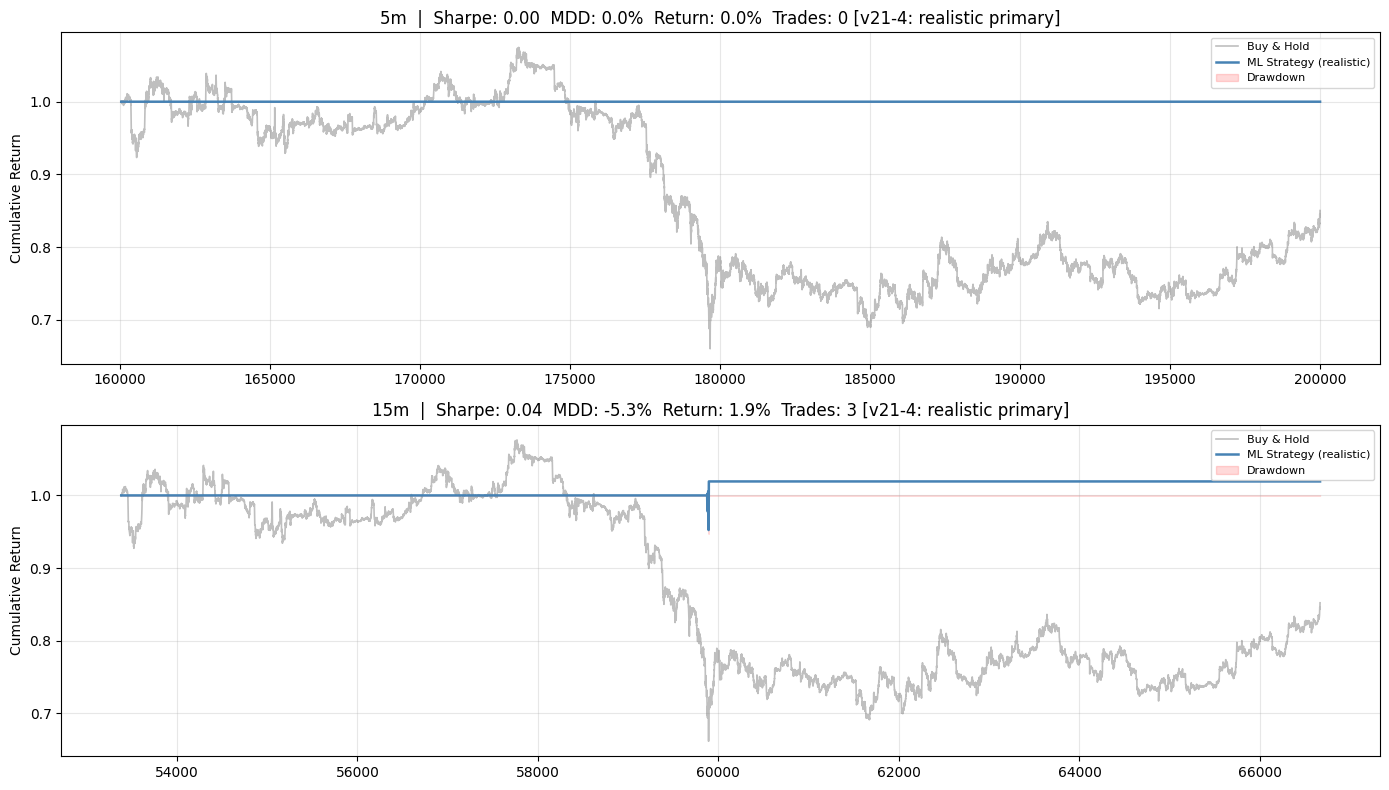

In [12]:
# Cell 6: Filtered backtest — v21
# [v21-4] REALISTIC-FIRST: primary profile = exec_delay=1 (next-bar open)
# [v21-8] Per-timeframe EDGE_FLOOR
# [v21-9] Daily loss circuit breaker
# Baseline (delay=0) kept for comparison only

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

COST_PER_TRADE = TAKER_FEE + (SLIPPAGE_BPS / 10_000)
TF_FUNDING_INTERVAL_BARS = {"5m": 96, "15m": 32}


def realistic_round_trip_cost(atr_pct_median):
    try:
        vol = float(atr_pct_median)
        if not np.isfinite(vol): vol = 0.002
    except Exception:
        vol = 0.002
    return (COST_PER_TRADE + (2*SPREAD_BPS + 2*SLIPPAGE_BASE_BPS)/10_000
            + 2*SLIPPAGE_VOL_COEF*vol)


def run_backtest(df, signal, price_col="close", exec_delay_bars=0,
                 atr_arr=None, atr_mult=1.5, hard_sl_pct=0.01, cost_pct=0.0005,
                 edge_arr=None, size_arr=None, edge_decay_thr=0.05,
                 min_hold_bars=5, min_profit_before_trail=0.0,
                 daily_dd_limit=0.03):   # [v21-9]

    price   = df[price_col].values
    n       = len(price)
    open_px = df["open"].values if "open" in df.columns else price.copy()
    dates   = df["datetime"].values if "datetime" in df.columns else np.arange(n)

    def fill_entry(bar_i):
        if exec_delay_bars <= 0: return float(price[bar_i])
        ei = min(bar_i + exec_delay_bars, n-1)
        return float(open_px[ei])

    _fallback_trail = 0.004
    position = 0; position_size = 0.0; entry_price = 0.0; stop_price = 0.0; entry_idx = None
    equity = [1.0]; trades = []

    # [v21-9] Daily circuit breaker state
    daily_equity_high = {pd.Timestamp(d).date() if hasattr(d, 'astype') else d: 1.0 for d in []}
    day_equity_start  = {}
    halted_days       = set()

    for i in range(1, n):
        p = price[i]
        sig = signal.iloc[i]
        bar_size = float(size_arr[i]) if size_arr is not None else 1.0

        # [v21-9] Daily circuit breaker: compute current equity, halt if day DD > limit
        try:
            bar_date = pd.Timestamp(dates[i]).date()
        except Exception:
            bar_date = None
        if bar_date is not None:
            if bar_date not in day_equity_start:
                day_equity_start[bar_date] = equity[-1]
            day_start_eq = day_equity_start[bar_date]
            cur_day_dd   = (equity[-1] - day_start_eq) / (day_start_eq + 1e-12)
            if cur_day_dd < -daily_dd_limit:
                halted_days.add(bar_date)

        atr_use = atr_arr[i] if (atr_arr is not None and not np.isnan(atr_arr[i]) and atr_arr[i] > 0) else p*_fallback_trail
        trail_dist = atr_mult * atr_use
        cur_edge   = abs(edge_arr[i]) if edge_arr is not None else 1.0
        prev_equity = equity[-1]

        if position == 1:
            stop_price = max(stop_price, p - trail_dist)
            bars_held  = i - entry_idx
            min_hold_ok = bars_held >= min_hold_bars
            unrealized  = (p - entry_price) / (entry_price + 1e-12)
            trail_armed = unrealized >= min_profit_before_trail
            hit_trail   = trail_armed and (p <= stop_price)
            hit_hard    = p <= entry_price * (1 - hard_sl_pct)
            edge_gone   = cur_edge < edge_decay_thr and min_hold_ok
            if min_hold_ok and (hit_trail or hit_hard or edge_gone):
                pnl = ((p - entry_price) / entry_price - cost_pct) * position_size
                trades.append({"type": "LONG", "entry": entry_price, "exit": p, "size": position_size,
                               "pnl": pnl, "bars": bars_held,
                               "exit_reason": "trail" if hit_trail else "hard_sl" if hit_hard else "edge_decay"})
                position = 0; position_size = 0.0

        elif position == -1:
            stop_price = min(stop_price, p + trail_dist)
            bars_held  = i - entry_idx
            min_hold_ok = bars_held >= min_hold_bars
            unrealized  = (entry_price - p) / (entry_price + 1e-12)
            trail_armed = unrealized >= min_profit_before_trail
            hit_trail   = trail_armed and (p >= stop_price)
            hit_hard    = p >= entry_price * (1 + hard_sl_pct)
            edge_gone   = cur_edge < edge_decay_thr and min_hold_ok
            if min_hold_ok and (hit_trail or hit_hard or edge_gone):
                pnl = ((entry_price - p) / entry_price - cost_pct) * position_size
                trades.append({"type": "SHORT", "entry": entry_price, "exit": p, "size": position_size,
                               "pnl": pnl, "bars": bars_held,
                               "exit_reason": "trail" if hit_trail else "hard_sl" if hit_hard else "edge_decay"})
                position = 0; position_size = 0.0

        if position == 0:
            # [v21-9] Skip entry if daily circuit breaker fired
            if bar_date in halted_days:
                pass
            elif sig == 2:
                position = 1; position_size = bar_size
                entry_price = fill_entry(i); stop_price = entry_price - trail_dist; entry_idx = i
            elif sig == 0:
                position = -1; position_size = bar_size
                entry_price = fill_entry(i); stop_price = entry_price + trail_dist; entry_idx = i
        else:
            if position == 1 and sig == 0 and (i - entry_idx) >= min_hold_bars:
                pnl = ((p - entry_price)/entry_price - cost_pct)*position_size
                trades.append({"type":"LONG","entry":entry_price,"exit":p,"size":position_size,
                               "pnl":pnl,"bars":i-entry_idx,"exit_reason":"flip"})
                position = -1; position_size = bar_size
                entry_price = fill_entry(i); stop_price = entry_price + trail_dist; entry_idx = i
            elif position == -1 and sig == 2 and (i - entry_idx) >= min_hold_bars:
                pnl = ((entry_price - p)/entry_price - cost_pct)*position_size
                trades.append({"type":"SHORT","entry":entry_price,"exit":p,"size":position_size,
                               "pnl":pnl,"bars":i-entry_idx,"exit_reason":"flip"})
                position = 1; position_size = bar_size
                entry_price = fill_entry(i); stop_price = entry_price - trail_dist; entry_idx = i

        if position == 1:
            ret = ((price[i] - price[i-1]) / price[i-1]) * position_size
        elif position == -1:
            ret = ((price[i-1] - price[i]) / price[i-1]) * position_size
        else:
            ret = 0.0
        equity.append(prev_equity * (1 + ret))

    if position != 0:
        p = price[-1]
        if position == 1:
            pnl, ttype = (((p-entry_price)/entry_price) - cost_pct)*position_size, "LONG"
        else:
            pnl, ttype = (((entry_price-p)/entry_price) - cost_pct)*position_size, "SHORT"
        trades.append({"type":ttype,"entry":entry_price,"exit":p,"size":position_size,
                       "pnl":pnl,"bars":n-entry_idx,"exit_reason":"forced"})

    equity = pd.Series(equity, index=df.index[:len(equity)])
    return equity, pd.DataFrame(trades), len(halted_days)


def evaluate_performance(equity, trades):
    returns    = equity.pct_change().dropna()
    sharpe     = np.sqrt(252) * returns.mean() / (returns.std() + 1e-9)
    cum_return = equity.iloc[-1] - 1
    drawdown   = equity / equity.cummax() - 1
    mdd        = drawdown.min()
    n_trades   = len(trades)
    win_rate   = (trades["pnl"] > 0).mean() if n_trades > 0 else 0.0
    avg_win    = float(trades.loc[trades["pnl"]>0,"pnl"].mean()) if n_trades>0 and (trades["pnl"]>0).any() else 0.0
    avg_loss   = float(-trades.loc[trades["pnl"]<=0,"pnl"].mean()) if n_trades>0 and (trades["pnl"]<=0).any() else 0.0
    trade_ev   = (win_rate * avg_win) - ((1.0 - win_rate) * avg_loss)
    return {"sharpe":sharpe,"return":cum_return,"mdd":mdd,"trades":n_trades,
            "win_rate":win_rate,"avg_win":avg_win,"avg_loss":avg_loss,"trade_ev":trade_ev}


def _empty_bt(tf, df):
    return {"timeframe":tf,"sharpe":0.0,"max_drawdown":0.0,"total_return":0.0,
            "bnh_return":0.0,"n_trades":0,"win_rate":0.0,"total_trade_cost":0.0,
            "n_holdout_bars":0,"df":df.iloc[0:0].copy()}


def run_backtest_v21(df_feat, model, feature_cols, tf, train_median=None,
                     exec_delay_bars=0, cost_round_trip=None, profile_name="realistic"):
    cost_rt = COST_PER_TRADE if cost_round_trip is None else float(cost_round_trip)
    edge_floor_tf = EDGE_FLOOR_TF.get(tf, EDGE_FLOOR)   # [v21-8]
    daily_dd_lim  = DAILY_DD_LIMIT_TF.get(tf, 0.03)     # [v21-9]

    df_bt = df_feat.copy()
    if len(df_bt) < 50:
        print(f"  {tf}: holdout too small ({len(df_bt)} bars)"); return _empty_bt(tf, df_feat)

    train_med = train_median if train_median is not None else pd.Series(dtype=float)
    df_bt_feats = df_bt.reindex(columns=feature_cols, fill_value=np.nan)
    for col in feature_cols:
        if col in train_med.index:
            df_bt_feats[col] = df_bt_feats[col].fillna(train_med[col])
    df_bt_feats = df_bt_feats.replace([np.inf, -np.inf], 0).fillna(0)

    edge     = model.predict(df_bt_feats.values)
    abs_edge = np.abs(edge)

    _rolling_thr = (
        pd.Series(abs_edge)
        .rolling(200, min_periods=20)
        .quantile(CONFIDENCE_PERCENTILE / 100.0)
        .fillna(np.percentile(abs_edge, CONFIDENCE_PERCENTILE))
        .values
    )
    threshold  = float(np.percentile(abs_edge, CONFIDENCE_PERCENTILE))
    total_cost = cost_rt * 2

    adx_arr     = df_bt["adx_14"].fillna(25).values if "adx_14" in df_bt.columns else np.full(len(df_bt), 25.0)
    atr_col     = "atr_14"
    atr_med     = df_bt[atr_col].median() if atr_col in df_bt.columns else 100.0
    atr_arr     = df_bt[atr_col].fillna(atr_med).values if atr_col in df_bt.columns else None
    atr_pct_arr = df_bt["atr_pct"].fillna(0).values if "atr_pct" in df_bt.columns else np.full(len(df_bt), 1.0)

    tf_confirm_arr = None
    if tf == "5m" and USE_15M_CONFIRMATION and TF_CONFIRM_COL_5M in df_bt.columns:
        tf_confirm_arr = df_bt[TF_CONFIRM_COL_5M].fillna(0).values

    signal = pd.Series(1, index=df_bt.index)
    last_trade_bar = -MIN_GAP_CANDLES - 1
    trades_today   = {}
    max_daily      = TF_MAX_TRADES_DAY.get(tf, 6)
    filter_counts  = {"edge_floor":0,"threshold":0,"cost":0,"regime_choppy":0,
                      "regime_panic":0,"gap":0,"daily_cap":0,"volatility":0,
                      "tf_confirm":0,"passed":0}

    for i in range(len(df_bt)):
        ae       = abs_edge[i]
        raw_edge = edge[i]
        adx_val  = adx_arr[i]
        vol_val  = atr_pct_arr[i]
        try:
            bar_date = df_bt["datetime"].iloc[i].date()
        except Exception:
            bar_date = None

        if ae < edge_floor_tf:    filter_counts["edge_floor"] += 1; continue     # [v21-8]
        if ae < _rolling_thr[i]:  filter_counts["threshold"] += 1; continue
        if ae < total_cost * MIN_EDGE_COST_RATIO: filter_counts["cost"] += 1; continue
        if adx_val < ADX_REGIME_MIN: filter_counts["regime_choppy"] += 1; continue
        if adx_val > ADX_REGIME_MAX: filter_counts["regime_panic"] += 1; continue
        if i - last_trade_bar < MIN_GAP_CANDLES: filter_counts["gap"] += 1; continue
        if bar_date and trades_today.get(bar_date, 0) >= max_daily:
            filter_counts["daily_cap"] += 1; continue
        if vol_val < VOLATILITY_FILTER_PCT: filter_counts["volatility"] += 1; continue
        if tf_confirm_arr is not None:
            trend = tf_confirm_arr[i]
            if raw_edge > 0 and trend <= 0: filter_counts["tf_confirm"] += 1; continue
            if raw_edge < 0 and trend >= 0: filter_counts["tf_confirm"] += 1; continue

        signal.iloc[i] = 2 if raw_edge > 0 else 0
        last_trade_bar = i
        if bar_date: trades_today[bar_date] = trades_today.get(bar_date, 0) + 1
        filter_counts["passed"] += 1

    if ENABLE_EDGE_POSITION_SIZING:
        size_arr = np.clip(abs_edge / (EDGE_SIZE_SCALE + 1e-12), MIN_POSITION_SIZE, MAX_POSITION_SIZE)
    else:
        size_arr = np.ones(len(df_bt), dtype=float)

    print(f"  [{profile_name}] exec_delay={exec_delay_bars}  cost_rt={cost_rt:.6f}  edge_floor={edge_floor_tf:.4f}")
    print(f"  Filters     : {filter_counts}")
    print(f"  Edge thresh : {threshold:.4f}  floor: {edge_floor_tf:.4f}  (top {100-CONFIDENCE_PERCENTILE}%)")
    print(f"  Position sz : mean={np.mean(size_arr):.3f}  min={np.min(size_arr):.3f}  max={np.max(size_arr):.3f}")

    df_bt["ml_signal"] = signal; df_bt["edge_strength"] = edge; df_bt["position_size"] = size_arr

    equity, trades_df, n_halted = run_backtest(
        df_bt, signal, price_col="close",
        exec_delay_bars=exec_delay_bars,
        atr_arr=atr_arr, atr_mult=ATR_TRAILING_MULT,
        hard_sl_pct=0.01, cost_pct=cost_rt,
        edge_arr=edge, size_arr=size_arr, edge_decay_thr=EDGE_DECAY_THRESHOLD,
        min_hold_bars=MIN_HOLD_BARS, min_profit_before_trail=MIN_PROFIT_BEFORE_TRAIL,
        daily_dd_limit=daily_dd_lim,
    )

    df_bt["market_return"] = df_bt["close"].pct_change()
    df_bt["cum_market"]    = (1 + df_bt["market_return"]).cumprod()
    df_bt["cum_strategy"]  = equity
    df_bt["drawdown"]      = equity / equity.cummax() - 1

    perf         = evaluate_performance(equity, trades_df)
    bnh_return   = float(df_bt["cum_market"].iloc[-1] - 1)
    total_tc     = len(trades_df) * cost_rt if len(trades_df) > 0 else 0

    if not trades_df.empty and "exit_reason" in trades_df.columns:
        print(f"  Exit reasons: {trades_df['exit_reason'].value_counts().to_dict()}")
    print(f"  Trade EV     : {perf['trade_ev']:.4%}  (avg_win={perf['avg_win']:.4%}, avg_loss={perf['avg_loss']:.4%})")
    if n_halted > 0:
        print(f"  ⚡ Circuit breaker triggered on {n_halted} day(s)  [v21-9]")

    return {
        "timeframe": tf, "profile": profile_name,
        "sharpe": round(perf["sharpe"], 4), "max_drawdown": round(perf["mdd"], 4),
        "total_return": round(perf["return"], 4), "bnh_return": round(bnh_return, 4),
        "n_trades": perf["trades"], "win_rate": round(perf["win_rate"], 4),
        "trade_ev": round(perf["trade_ev"], 6),
        "avg_win": round(perf["avg_win"], 6), "avg_loss": round(perf["avg_loss"], 6),
        "total_trade_cost": round(total_tc, 6), "total_funding_cost": 0.0,
        "n_holdout_bars": len(df_bt), "df": df_bt, "trades": trades_df,
    }


# ── Execute backtests ─────────────────────────────────────────────────────────
backtest_results = {}
for tf in TIMEFRAMES:
    res = training_results.get(tf, {})
    if not res or res.get("model") is None:
        print(f"\n  {tf}: no model — skipping backtest"); continue

    print(f"\n{'='*60}\nBacktesting: {tf}")
    feature_cols  = training_results[tf]["features"]
    train_median_ = training_results[tf].get("train_median")

    hold_df      = holdout_splits[tf]
    atr_pct_med  = float(hold_df["atr_pct"].median()) if "atr_pct" in hold_df.columns else 0.002
    cost_real    = realistic_round_trip_cost(atr_pct_med)

    # [v21-4] Realistic is PRIMARY; baseline is comparison
    profiles = [
        ("realistic", EXECUTION_DELAY_BARS, cost_real),          # [v21-4] PRIMARY
        ("baseline",  EXECUTION_DELAY_BARS_BASELINE, None),      # reference
    ] if BACKTEST_RUN_DUAL else [("realistic", EXECUTION_DELAY_BARS, cost_real)]

    bt_main = None; rows_cmp = []
    for pname, delay, crt in profiles:
        bt = run_backtest_v21(hold_df, res["model"], feature_cols, tf,
                               train_median=train_median_, exec_delay_bars=delay,
                               cost_round_trip=crt, profile_name=pname)
        rows_cmp.append({
            "profile": pname, "delay": delay,
            "sharpe": bt["sharpe"], "return": bt["total_return"],
            "mdd": bt["max_drawdown"], "trades": bt["n_trades"],
            "ev": bt.get("trade_ev", 0.0), "cost": bt["total_trade_cost"],
        })
        if pname == "realistic":   # [v21-4] primary = realistic
            bt_main = bt

    if BACKTEST_RUN_DUAL and len(rows_cmp) > 1:
        print("\n  --- Backtest profile comparison [v21-4: realistic=primary] ---")
        for row in rows_cmp:
            marker = " ← PRIMARY [v21-4]" if row["profile"] == "realistic" else ""
            print(f"    {row['profile']:<12} delay={row['delay']}  Sharpe={row['sharpe']:.4f}  "
                  f"Ret={row['return']:.2%}  MDD={row['mdd']:.2%}  Trades={row['trades']}  "
                  f"EV={row['ev']:.4%}{marker}")

    backtest_results[tf] = bt_main if bt_main is not None else bt

    bt = backtest_results[tf]
    print(f"\n  (Primary = realistic profile, exec_delay={EXECUTION_DELAY_BARS})")
    print(f"  Sharpe Ratio         : {bt['sharpe']:>8.4f}")
    print(f"  Max Drawdown         : {bt['max_drawdown']:>8.2%}")
    print(f"  Total Return         : {bt['total_return']:>8.2%}")
    print(f"  Buy-and-Hold Return  : {bt['bnh_return']:>8.2%}")
    print(f"  Win Rate             : {bt['win_rate']:>8.2%}")
    print(f"  Trade EV             : {bt.get('trade_ev', 0.0):>8.2%}")
    print(f"  Trades               : {bt['n_trades']:>8}")
    print(f"  Trade Cost (total)   : {bt['total_trade_cost']:>10.4%}")

    if "trades" in bt and not bt["trades"].empty:
        print("  Sample trades:")
        print(bt["trades"].head().to_string(index=False))

    if   bt["sharpe"] >= 1.5: print("  Sharpe >= 1.5 — institutional grade")
    elif bt["sharpe"] >= 1.0: print("  Sharpe >= 1.0 — strong; ready for paper trading")
    elif bt["sharpe"] >= 0.5: print("  Sharpe 0.5-1.0 — acceptable; monitor live")
    elif bt["sharpe"] >= 0:   print("  Sharpe 0-0.5 — marginal; tune EDGE_FLOOR or TOP_N")
    else:                     print("  Negative Sharpe — check label config or feature set")


# ── Equity curves ─────────────────────────────────────────────────────────────
n_tf = len(TIMEFRAMES)
fig, axes = plt.subplots(n_tf, 1, figsize=(14, 4*n_tf), squeeze=False)
for ax, tf in zip(axes[:, 0], TIMEFRAMES):
    bt = backtest_results.get(tf)
    if bt is None or bt["df"].empty:
        ax.text(0.5, 0.5, f"{tf}: no data", transform=ax.transAxes, ha="center"); continue
    df_bt = bt["df"]
    ax.plot(df_bt.index, df_bt["cum_market"],   label="Buy & Hold",             alpha=0.5, lw=1.2, color="gray")
    ax.plot(df_bt.index, df_bt["cum_strategy"], label="ML Strategy (realistic)", lw=1.8,   color="steelblue")
    ax.fill_between(df_bt.index, df_bt["drawdown"]+1, 1, alpha=0.15, color="red", label="Drawdown")
    ax.set_title(f"{tf}  |  Sharpe: {bt['sharpe']:.2f}  MDD: {bt['max_drawdown']:.1%}"
                 f"  Return: {bt['total_return']:.1%}  Trades: {bt['n_trades']} [v21-4: realistic primary]")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylabel("Cumulative Return")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "backtest_equity_curves_v21.png", dpi=120, bbox_inches="tight")
plt.show()


In [13]:
# Cell 7: SHAP Feature Importance — v21
# [v21-1] SHAP drawn from the regressor component of the ensemble

import shap
import numpy as np

for tf in TIMEFRAMES:
    res = training_results.get(tf, {})
    if not res or res.get("reg") is None:
        print(f"{tf}: no model"); continue

    df           = train_splits[tf]
    feature_cols = training_results[tf]["features"]
    train_med    = training_results[tf].get("train_median", pd.Series(dtype=float))
    X_df = df.reindex(columns=feature_cols, fill_value=np.nan)
    if train_med is not None and len(train_med) > 0:
        X_df = X_df.fillna(train_med)
    X_s = X_df.replace([np.inf, -np.inf], 0).fillna(0).values

    sample_size = min(2000, len(X_s))
    np.random.seed(RANDOM_STATE)
    X_sample = X_s[np.random.choice(len(X_s), sample_size, replace=False)]

    # [v21-1] SHAP on regressor (continuous edge predictor)
    reg_model = res["reg"]
    try:
        explainer   = shap.TreeExplainer(reg_model)
        shap_values = explainer.shap_values(X_sample)
    except Exception as e:
        print(f"  SHAP failed for {tf}: {e}"); continue

    if isinstance(shap_values, list):
        mean_abs_shap = np.mean([np.mean(np.abs(sv), axis=0) for sv in shap_values], axis=0)
    else:
        abs_s = np.abs(shap_values)
        mean_abs_shap = (np.mean(np.mean(abs_s, axis=0), axis=1)
                         if abs_s.ndim == 3 else np.mean(abs_s, axis=0))

    top_idx      = np.argsort(mean_abs_shap)[-20:][::-1]
    top_features = [(feature_cols[i], mean_abs_shap[i]) for i in top_idx]
    max_imp      = max(mean_abs_shap) + 1e-12

    print(f"\n{tf} -- Top 20 Features (mean |SHAP| on regressor) [v21-1]:")
    for feat, imp in top_features:
        bar = "#" * int(imp / max_imp * 30)
        print(f"  {feat:<40} {imp:.5f}  {bar}")

print("\nSHAP analysis complete (v21).")



5m -- Top 20 Features (mean |SHAP| on regressor) [v21-1]:
  ema_9                                    0.00088  ##############################
  atr_14                                   0.00082  ###########################
  adx_14                                   0.00071  ########################
  bb_width                                 0.00053  ##################
  macd_hist_15m                            0.00045  ###############
  roc_20                                   0.00044  ###############
  adx_14_15m                               0.00042  ##############
  atr_ratio                                0.00040  #############
  volatility_10                            0.00038  #############
  price_vs_ema200                          0.00036  ############
  volatility                               0.00033  ###########
  ema_cross_50_200_15m                     0.00030  ##########
  vol_ratio_mt_lt                          0.00029  #########
  trend_strength                         

In [14]:
# Cell 8: ModelRegistry + RetrainEngine — v21
# Compatible with EnsembleModel (clf + reg) introduced in v21-1
# Warm-start retrains BOTH clf and reg components

import json, pickle, time
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.base import clone
from sklearn.metrics import f1_score
from scipy.stats import ks_2samp
from pathlib import Path


class ModelRegistry:
    def __init__(self, base_dir):
        self.base_dir    = Path(base_dir)
        self.base_dir.mkdir(parents=True, exist_ok=True)
        self._cache      = {}
        self._retrain_ts = {}
        self._log_path   = self.base_dir / "retrain_log.json"

    def save_version(self, tf, pipeline, tag):
        version_dir = self.base_dir / f"model_{tf}_{tag}"
        version_dir.mkdir(parents=True, exist_ok=True)
        versioned_path = version_dir / f"pipeline_{tf}_{tag}.pkl"
        latest_path    = self.base_dir / f"pipeline_{tf}_latest.pkl"
        with open(versioned_path, "wb") as fh: pickle.dump(pipeline, fh)
        with open(latest_path,    "wb") as fh: pickle.dump(pipeline, fh)
        self._cache[tf]      = pipeline
        self._retrain_ts[tf] = time.time()
        print(f"  [Registry] Saved {tf} version={tag}")
        return versioned_path

    def load_latest(self, tf):
        if tf in self._cache: return self._cache[tf]
        p = self.base_dir / f"pipeline_{tf}_latest.pkl"
        if not p.exists(): return None
        with open(p, "rb") as fh: pipeline = pickle.load(fh)
        self._cache[tf] = pipeline
        return pipeline

    def load_version(self, tf, tag):
        p = self.base_dir / f"model_{tf}_{tag}" / f"pipeline_{tf}_{tag}.pkl"
        if not p.exists(): return None
        with open(p, "rb") as fh: return pickle.load(fh)

    def rollback(self, tf, tag):
        pipeline = self.load_version(tf, tag)
        if pipeline is None: return False
        latest_path = self.base_dir / f"pipeline_{tf}_latest.pkl"
        with open(latest_path, "wb") as fh: pickle.dump(pipeline, fh)
        self._cache[tf] = pipeline
        print(f"  [Registry:{tf}] Rolled back to version {tag}")
        return True

    def cooldown_remaining(self, tf, hours):
        last = self._retrain_ts.get(tf, 0.0) or self._last_retrain_from_log(tf)
        if not last: return 0.0
        return max(0.0, hours - (time.time() - last) / 3600)

    def log_retrain(self, entry):
        entries = self._load_log(); entries.append(entry)
        with open(self._log_path, "w") as fh: json.dump(entries, fh, indent=2)

    def _load_log(self):
        if not self._log_path.exists(): return []
        try:
            with open(self._log_path) as fh: return json.load(fh)
        except Exception: return []

    def _last_retrain_from_log(self, tf):
        entries = [e for e in self._load_log() if e.get("tf") == tf]
        if not entries: return 0.0
        try: return pd.Timestamp(entries[-1]["time"]).timestamp()
        except Exception: return 0.0

    def list_versions(self, tf):
        return sorted([d.name for d in self.base_dir.iterdir()
                       if d.is_dir() and d.name.startswith(f"model_{tf}_")])

    def invalidate_cache(self, tf): self._cache.pop(tf, None)


def hot_reload_model(tf, registry):
    registry.invalidate_cache(tf)
    pipeline = registry.load_latest(tf)
    if pipeline is None:
        print(f"  [HotReload:{tf}] No pipeline on disk"); return None
    version    = pipeline.get("meta", {}).get("model_version", "?")
    retrained  = pipeline.get("meta", {}).get("retrained_at", "")
    print(f"  [HotReload:{tf}] Loaded version={version}"
          + (f"  retrained_at={retrained[:19]}" if retrained else ""))
    return pipeline


class RetrainEngine:
    def __init__(self, registry, training_results, labeled_data,
                 cooldown_hours=RETRAIN_COOLDOWN_HOURS,
                 drift_feature_limit=DRIFT_FEATURE_LIMIT,
                 validation_min_f1_delta=0.005,
                 drift_persistence_cycles=DRIFT_PERSISTENCE_CYCLES,
                 min_retrain_samples=MIN_RETRAIN_SAMPLES):
        self.registry   = registry; self.tr = training_results; self.ld = labeled_data
        self.cooldown_h = cooldown_hours; self.drift_limit = drift_feature_limit
        self.min_f1_delta = validation_min_f1_delta
        self.drift_persistence = drift_persistence_cycles
        self.min_samples = min_retrain_samples
        self._drift_counts = {}

    def maybe_retrain(self, tf):
        print(f"\n[RetrainEngine:{tf}] Starting adaptive check")
        if not self._has_base_model(tf): return False
        remaining = self.registry.cooldown_remaining(tf, self.cooldown_h)
        if remaining > 0:
            print(f"  Cooldown: {remaining:.1f}h remaining — skip"); return False

        df           = self.ld.get(tf, pd.DataFrame())
        feature_cols = self.tr[tf]["features"]
        if len(df) < 40_000:
            print(f"  Insufficient data ({len(df):,}) — skip"); return False

        drifted = self._detect_drift(df, feature_cols)
        print(f"  Drifted features: {len(drifted)}" +
              (f" {[d[0] for d in drifted[:3]]}..." if len(drifted) > 3 else f" {[d[0] for d in drifted]}"))

        if len(drifted) <= self.drift_limit:
            print(f"  Drift ({len(drifted)}) <= limit ({self.drift_limit}) — stable"); self._drift_counts[tf] = 0; return False

        self._drift_counts[tf] = self._drift_counts.get(tf, 0) + 1
        cycles = self._drift_counts[tf]
        if cycles < self.drift_persistence:
            print(f"  Drift confirmed {cycles}/{self.drift_persistence} cycles — waiting"); return False

        print(f"  Drift confirmed over {cycles} cycles — RETRAINING")
        self._drift_counts[tf] = 0

        df_clean = self._prepare_window(df, feature_cols)
        if df_clean is None: return False
        if len(df_clean) < self.min_samples:
            print(f"  ❌ Window too small: {len(df_clean):,} < {self.min_samples:,}"); return False

        new_model, new_median_dict, f1_train = self._warm_retrain(tf, df_clean, feature_cols)
        accepted = self._validate(tf, df_clean, feature_cols, new_model)
        if not accepted: return False

        old_f1, new_f1, old_wr, new_wr = accepted
        version_tag = f"v_auto_{int(time.time())}"
        pipeline = {
            "model": new_model, "features": feature_cols,
            "train_median": new_median_dict,
            "meta": {**self.tr[tf].get("meta",{}),
                     "retrained_at": pd.Timestamp.now("UTC").isoformat(),
                     "retrain_method": "warm_start", "new_f1": float(new_f1)},
        }
        # [v21-1] Also include clf/reg separately for EnsembleModel reconstruction
        if hasattr(new_model, "clf"):
            pipeline["clf"] = new_model.clf; pipeline["reg"] = new_model.reg
        self.registry.save_version(tf, pipeline, version_tag)
        self.tr[tf]["model"] = new_model; self.tr[tf]["train_median"] = pd.Series(new_median_dict)
        self.registry.log_retrain({"tf":tf,"time":pd.Timestamp.now("UTC").isoformat(),
                                   "version":version_tag,"drifted":len(drifted),
                                   "n_samples":len(df_clean),"old_f1":round(float(old_f1),4),
                                   "new_f1":round(float(new_f1),4)})
        print(f"  ✅ ACCEPTED  version={version_tag}")
        print(f"     F1: {old_f1:.4f} → {new_f1:.4f} | WinRate: {old_wr:.3f} → {new_wr:.3f}")
        return True

    def _has_base_model(self, tf):
        res = self.tr.get(tf, {})
        if not res or res.get("model") is None:
            print(f"  No base model for {tf}"); return False
        return True

    def _detect_drift(self, df, feature_cols):
        df_recent = df.iloc[-20_000:]
        nan_ratio = df_recent[feature_cols].isna().mean().mean()
        if nan_ratio > MAX_MISSING_DATA_RATIO_DRIFT:
            print(f"  ⚠️  Drift detection SKIPPED: NaN ratio={nan_ratio:.1%}"); return []
        drifted = []
        df_past = df.iloc[-40_000:-20_000]
        for col in feature_cols:
            if col not in df.columns: continue
            a = df_past[col].dropna().values; b = df_recent[col].dropna().values
            if len(a) < 30 or len(b) < 30: continue
            stat, p = ks_2samp(a, b)
            if p < DRIFT_ALPHA and stat > DRIFT_STAT_THRESHOLD: drifted.append((col, round(p,6), round(stat,4)))
        return drifted

    def _prepare_window(self, df, feature_cols):
        cutoff   = df["datetime"].max() - pd.Timedelta(days=ROLLING_DAYS)
        df_train = df[df["datetime"] >= cutoff].copy()
        df_clean = df_train[feature_cols + ["label","target_net_return"]].copy()
        df_clean[feature_cols] = df_clean[feature_cols].replace([np.inf,-np.inf], np.nan).ffill(limit=5)
        df_clean = df_clean.dropna(subset=["label","target_net_return"])
        if len(df_clean) < 1_000:
            print(f"  Window too small ({len(df_clean)}) — skip"); return None
        return df_clean

    def _warm_retrain(self, tf, df_clean, feature_cols):
        old_model = self.tr[tf]["model"]
        median_s  = df_clean[feature_cols].median()
        X         = df_clean[feature_cols].fillna(median_s).values
        y_reg     = df_clean["target_net_return"].values
        y_cls     = df_clean["label"].values
        sw        = focal_sample_weights(y_cls, y_reg, LABEL_MIN_NET_EDGE)

        # Warm-start both models
        old_clf  = self.tr[tf].get("clf") or old_model.clf
        old_reg  = self.tr[tf].get("reg") or old_model.reg
        new_clf  = clone(old_clf); new_clf._Booster = xgb.train(
            dict(old_clf.get_xgb_params()), xgb.DMatrix(X, label=y_cls, weight=sw),
            num_boost_round=NUM_BOOST_ROUND_INCREMENTAL,
            xgb_model=old_clf.get_booster(), verbose_eval=False)
        new_reg  = clone(old_reg); new_reg._Booster = xgb.train(
            dict(old_reg.get_xgb_params()), xgb.DMatrix(X, label=y_reg, weight=sw),
            num_boost_round=NUM_BOOST_ROUND_INCREMENTAL,
            xgb_model=old_reg.get_booster(), verbose_eval=False)

        new_model = EnsembleModel(new_clf, new_reg)
        pred      = new_model.predict(X)
        pred_cls  = np.ones(len(pred), dtype=int)
        pred_cls[pred > LABEL_MIN_NET_EDGE]  = 2
        pred_cls[pred < -LABEL_MIN_NET_EDGE] = 0
        f1 = f1_score(y_cls, pred_cls, average="macro", zero_division=0)
        print(f"  Warm-start retrain: F1_proxy={f1:.4f}  Samples={len(y_reg):,}")
        return new_model, median_s.to_dict(), f1

    def _validate(self, tf, df_clean, feature_cols, new_model):
        old_model = self.tr[tf]["model"]
        prod_med  = self.tr[tf].get("train_median")
        prod_med  = prod_med.to_dict() if hasattr(prod_med, "to_dict") else (prod_med or {})
        n_val    = min(VALIDATION_WINDOW_ROWS, len(df_clean))
        df_val   = df_clean.iloc[-n_val:].dropna(subset=["label"])
        if len(df_val) < MIN_VAL_ROWS:
            print(f"  Validation set too small ({len(df_val)}) — REJECT"); return None
        X_val = df_val[feature_cols].fillna(prod_med).values
        y_val = df_val["label"].values

        def _predict_cls(model, X):
            edge = model.predict(X)
            p    = np.ones(len(edge), dtype=int)
            p[edge > LABEL_MIN_NET_EDGE] = 2; p[edge < -LABEL_MIN_NET_EDGE] = 0
            return p

        old_pred = _predict_cls(old_model, X_val)
        new_pred = _predict_cls(new_model, X_val)
        old_f1   = f1_score(y_val, old_pred, average="macro", zero_division=0)
        new_f1   = f1_score(y_val, new_pred, average="macro", zero_division=0)

        def _wr(y_true, y_pred):
            mask = y_pred != 1
            return (y_true[mask] == y_pred[mask]).mean() if mask.sum() > 0 else 0.5

        old_wr = _wr(y_val, old_pred); new_wr = _wr(y_val, new_pred)
        print(f"  Validation — old_F1={old_f1:.4f}  new_F1={new_f1:.4f}  old_WR={old_wr:.3f}  new_WR={new_wr:.3f}")

        if new_f1 < old_f1 + self.min_f1_delta:
            print(f"  REJECTED — F1 did not improve by {self.min_f1_delta:.4f}"); return None
        if new_wr < old_wr - 0.02:
            print(f"  REJECTED — Win-rate dropped more than 2pp"); return None
        return old_f1, new_f1, old_wr, new_wr


# ── Init and run ──────────────────────────────────────────────────────────────
model_registry = ModelRegistry(OUTPUT_DIR)
for tf, res in training_results.items():
    if res.get("model") is not None:
        pipeline = {"model": res["model"], "features": res["features"],
                    "train_median": (res["train_median"].to_dict()
                                     if hasattr(res.get("train_median"), "to_dict")
                                     else res.get("train_median", {})),
                    "meta": res.get("meta", {})}
        if res.get("clf"): pipeline["clf"] = res["clf"]
        if res.get("reg"): pipeline["reg"] = res["reg"]
        model_registry._cache[tf] = pipeline

retrain_engine = RetrainEngine(registry=model_registry, training_results=training_results,
                                labeled_data=labeled_data, cooldown_hours=RETRAIN_COOLDOWN_HOURS,
                                drift_feature_limit=DRIFT_FEATURE_LIMIT, validation_min_f1_delta=0.005)

print("=" * 60)
print("ADAPTIVE ENGINE v21 — ModelRegistry + RetrainEngine")
print("=" * 60)

adaptive_triggered = {}
for tf in TIMEFRAMES:
    triggered = retrain_engine.maybe_retrain(tf)
    adaptive_triggered[tf] = triggered
    if not triggered: print(f"  [{tf}] No adaptive update triggered — model unchanged")

print(f"\nAdaptive results: {adaptive_triggered}")
print("\nAvailable registry versions:")
for tf in TIMEFRAMES:
    print(f"  {tf}: {model_registry.list_versions(tf)}")

print("\n─── Hot-reload test ───────────────────────────────────────")
for tf in TIMEFRAMES:
    pipeline = hot_reload_model(tf, model_registry)
    if pipeline:
        meta = pipeline.get("meta", {})
        print(f"  {tf}: version={meta.get('model_version','?')}  features={len(pipeline.get('features',[]))}")

print("\n─── Agent integration snippet ─────────────────────────────")
print("""
# In your live trading agent:
from pathlib import Path; import pickle

OUTPUT_DIR = Path('/content/drive/MyDrive/JackSparrow_Models')

def load_live_model(tf):
    with open(OUTPUT_DIR / f'pipeline_{tf}_latest.pkl', 'rb') as fh:
        return pickle.load(fh)

# In live loop — reconstruct EnsembleModel if needed:
pipeline = load_live_model('15m')
model    = pipeline['model']   # EnsembleModel with .predict() method
features = pipeline['features']
median   = pipeline['train_median']

# Every N hours, check and retrain:
# retrain_engine.maybe_retrain('5m')
# retrain_engine.maybe_retrain('15m')
""")


ADAPTIVE ENGINE v21 — ModelRegistry + RetrainEngine

[RetrainEngine:5m] Starting adaptive check
  Cooldown: 13.6h remaining — skip
  [5m] No adaptive update triggered — model unchanged

[RetrainEngine:15m] Starting adaptive check
  Cooldown: 13.6h remaining — skip
  [15m] No adaptive update triggered — model unchanged

Adaptive results: {'5m': False, '15m': False}

Available registry versions:
  5m: ['model_5m_v10', 'model_5m_v14', 'model_5m_v16', 'model_5m_v21', 'model_5m_v9', 'model_5m_v_auto_1776397445']
  15m: ['model_15m_v10', 'model_15m_v14', 'model_15m_v16', 'model_15m_v21', 'model_15m_v9', 'model_15m_v_auto_1776397447']

─── Hot-reload test ───────────────────────────────────────
  [HotReload:5m] Loaded version=v21
  5m: version=v21  features=20
  [HotReload:15m] Loaded version=v21
  15m: version=v21  features=20

─── Agent integration snippet ─────────────────────────────

# In your live trading agent:
from pathlib import Path; import pickle

OUTPUT_DIR = Path('/content/drive/

In [15]:
# Cell 9: Final Validation Summary — v21
print("\n" + "=" * 60)
print("FINAL VALIDATION SUMMARY  (JackSparrow v21)")
print("=" * 60)
print("Model  : EnsembleModel(XGBClassifier × XGBRegressor)  [v21-1]")
print("Signal : ensemble_edge = dir_conf × |reg_edge| (sign from classifier)")
print("Primary: exec_delay=1 (realistic-first)  [v21-4]")
print("Exits  : ATR trailing | hard SL | edge decay | min hold | daily DD limit [v21-9]")
print("=" * 60)

all_pass = True
for tf in TIMEFRAMES:
    res = training_results.get(tf, {})
    bt  = backtest_results.get(tf, {})

    if not res or res.get("model") is None:
        print(f"\n  {tf}: NO MODEL TRAINED"); all_pass = False; continue

    n_train      = len(train_splits.get(tf, pd.DataFrame()))
    n_holdout    = len(holdout_splits.get(tf, pd.DataFrame()))
    mean_f1      = res.get("mean_f1", 0)
    mean_pearson = res.get("mean_pearson", float("nan"))
    sharpe       = bt.get("sharpe")
    mdd          = bt.get("max_drawdown")
    ret          = bt.get("total_return")
    n_trades     = bt.get("n_trades")
    win_rate     = bt.get("win_rate")
    n_feat       = len(res.get("features", []))
    was_updated  = adaptive_triggered.get(tf, False)
    model_tag    = res.get("meta", {}).get("model_version", "v21")

    print(f"\n  {tf}:")
    print(f"    model_version        : {model_tag}" + (" [ADAPTIVE UPDATE APPLIED]" if was_updated else ""))
    print(f"    model_type           : EnsembleModel (clf × reg)  [v21-1]")
    print(f"    features selected    : {n_feat}")
    print(f"    training rows        : {n_train:,}  (holdout: {n_holdout:,} rows)")
    print(f"    cv_f1_macro (honest) : {mean_f1:.4f}  [TimeSeriesSplit, no leakage]")
    print(f"    cv_pearsonr          : {mean_pearson:.4f}  [v21-6: discard folds |R|<{PEARSONR_MIN}]")
    print(f"    backtest.sharpe      : {sharpe}  [realistic, exec_delay=1, v21-4]")
    print(f"    backtest.mdd         : {mdd:.2%}" if mdd is not None else "    backtest.mdd : N/A")
    print(f"    backtest.return      : {ret:.2%}" if ret is not None else "    backtest.return : N/A")
    print(f"    backtest.trades      : {n_trades}")
    print(f"    backtest.win_rate    : {win_rate:.2%}" if win_rate is not None else "    backtest.win_rate : N/A")
    print(f"    edge_floor           : {EDGE_FLOOR_TF.get(tf, EDGE_FLOOR):.4f}  [v21-8]")
    print(f"    daily_dd_limit       : {DAILY_DD_LIMIT_TF.get(tf, 0.03):.1%}  [v21-9]")

    registry_versions = model_registry.list_versions(tf)
    print(f"    registry versions    : {registry_versions}")

    if sharpe is None: print("    WARN: No backtest result")
    elif sharpe >= 1.5: print("    PASS: Sharpe >= 1.5 — institutional grade")
    elif sharpe >= 1.0: print("    PASS: Sharpe >= 1.0 — strong; ready for paper trading")
    elif sharpe >= 0.5: print("    PASS: Sharpe 0.5-1.0 — acceptable; monitor live")
    elif sharpe >= 0:   print("    MARGINAL: Sharpe 0-0.5 — tune EDGE_FLOOR or TOP_N"); all_pass = False
    else:               print("    FAIL: Negative Sharpe — review label config or feature set"); all_pass = False

    if mean_pearson < 0.03:
        print(f"    ⚠️  Low CV PearsonR ({mean_pearson:.4f}) — ensemble may lack edge; consider more data")
        all_pass = False

print(f"\n{'=' * 60}")
if all_pass:
    print("ALL TIMEFRAMES VALIDATED — ready for paper trading")
    print(f"   Output: {OUTPUT_DIR}")
else:
    print("REVIEW REQUIRED — address warnings above before going live")

print("""
Quick-tune knobs (Cell 1) — v21 additions:
  LABEL_MIN_NET_EDGE    (default 0.0030 / 30 bps) — raise for tighter labels  [v21-7]
  TF_LOOKAHEAD          (default {"5m":15,"15m":12}) — shorten for cleaner labels  [v21-2]
  EDGE_FLOOR_TF         (per-tf dict) — raise to reduce trade frequency  [v21-8]
  DAILY_DD_LIMIT_TF     (per-tf dict) — tighten to cap daily losses  [v21-9]
  CONFIDENCE_PERCENTILE (default 80) — raise for stronger signal filter
  CORR_THRESHOLD        (default 0.92) — lower for more aggressive pruning  [v21]
  TOP_N_FEATURES        (default 20) — lower to reduce noise
  ATR_TRAILING_MULT     (default 1.5) — raise for wider stop
  MIN_HOLD_BARS         (default 5) — raise to prevent premature exits
  TF_MAX_TRADES_DAY     (5m:6, 15m:4) — lower to reduce over-trading  [v21]
  PEARSONR_MIN          (default 0.02) — raise to be more selective on folds  [v21-6]
  RETRAIN_LIGHTWEIGHT   (default False) — set True for fast warm-start retrains
""")



FINAL VALIDATION SUMMARY  (JackSparrow v21)
Model  : EnsembleModel(XGBClassifier × XGBRegressor)  [v21-1]
Signal : ensemble_edge = dir_conf × |reg_edge| (sign from classifier)
Primary: exec_delay=1 (realistic-first)  [v21-4]
Exits  : ATR trailing | hard SL | edge decay | min hold | daily DD limit [v21-9]

  5m:
    model_version        : v21
    model_type           : EnsembleModel (clf × reg)  [v21-1]
    features selected    : 20
    training rows        : 159,785  (holdout: 39,950 rows)
    cv_f1_macro (honest) : 0.3566  [TimeSeriesSplit, no leakage]
    cv_pearsonr          : 0.0532  [v21-6: discard folds |R|<0.02]
    backtest.sharpe      : 0.0  [realistic, exec_delay=1, v21-4]
    backtest.mdd         : 0.00%
    backtest.return      : 0.00%
    backtest.trades      : 0
    backtest.win_rate    : 0.00%
    edge_floor           : 0.0030  [v21-8]
    daily_dd_limit       : 2.0%  [v21-9]
    registry versions    : ['model_5m_v10', 'model_5m_v14', 'model_5m_v16', 'model_5m_v21', 'mo

In [16]:
# Cell 10: Download model artifacts — v21
import shutil, tempfile
from pathlib import Path

temp_dir  = tempfile.mkdtemp()
temp_path = Path(temp_dir)

print(f"Selective download: v21 models for {TIMEFRAMES}")
copied_items = []

for tf in TIMEFRAMES:
    for tag in ["v21", "v18", "v17", "v16", "v14"]:
        src_dir = OUTPUT_DIR / f"model_{tf}_{tag}"
        if src_dir.exists():
            dst_dir = temp_path / f"model_{tf}_{tag}"
            shutil.copytree(src_dir, dst_dir)
            copied_items.append(f"model_{tf}_{tag}")
            print(f"  ✓ Copied: {src_dir.name}")
            break
    for version_dir in OUTPUT_DIR.glob(f"model_{tf}_v_auto_*"):
        dst_dir = temp_path / version_dir.name
        if not dst_dir.exists():
            shutil.copytree(version_dir, dst_dir)
            copied_items.append(version_dir.name)
            print(f"  ✓ Copied adaptive: {version_dir.name}")
    latest = OUTPUT_DIR / f"pipeline_{tf}_latest.pkl"
    if latest.exists():
        shutil.copy2(latest, temp_path / latest.name)
        copied_items.append(latest.name)
        print(f"  ✓ Copied: {latest.name}")

for plot_name in ["backtest_equity_curves_v21.png", "backtest_equity_curves_v19.png"]:
    plot_src = OUTPUT_DIR / plot_name
    if plot_src.exists():
        shutil.copy2(plot_src, temp_path / plot_name)
        copied_items.append(plot_name); print(f"  ✓ Copied: {plot_name}"); break

log_src = OUTPUT_DIR / "retrain_log.json"
if log_src.exists():
    shutil.copy2(log_src, temp_path / "retrain_log.json")
    copied_items.append("retrain_log.json"); print(f"  ✓ Copied: retrain_log.json")

if not copied_items:
    print("  ❌ No models found to download!")
else:
    print(f"  📦 Items ({len(copied_items)}): {copied_items}")
    zip_base = "/content/JackSparrow_Models_v21"
    zip_path = zip_base + ".zip"
    shutil.make_archive(zip_base, "zip", root_dir=temp_dir, base_dir=".")
    print(f"  Archive: {zip_path}")
    try:
        from google.colab import files
        files.download(zip_path)
        print("  Download triggered.")
    except ImportError:
        print(f"  Not in Colab. Archive at: {zip_path}")

shutil.rmtree(temp_dir)
print("Done.")


Selective download: v21 models for ['5m', '15m']
  ✓ Copied: model_5m_v21
  ✓ Copied adaptive: model_5m_v_auto_1776397445
  ✓ Copied: pipeline_5m_latest.pkl
  ✓ Copied: model_15m_v21
  ✓ Copied adaptive: model_15m_v_auto_1776397447
  ✓ Copied: pipeline_15m_latest.pkl
  ✓ Copied: backtest_equity_curves_v21.png
  ✓ Copied: retrain_log.json
  📦 Items (8): ['model_5m_v21', 'model_5m_v_auto_1776397445', 'pipeline_5m_latest.pkl', 'model_15m_v21', 'model_15m_v_auto_1776397447', 'pipeline_15m_latest.pkl', 'backtest_equity_curves_v21.png', 'retrain_log.json']
  Archive: /content/JackSparrow_Models_v21.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Download triggered.
Done.
